# Model Analysis: NASDAQ-100 Microstructure

This notebook evaluates all predictive models trained on the NASDAQ-100
microstructure case study and answers a single question: **which learned
signals are real, stable, and worth taking into a backtest?**

This is the highest-frequency case study in the book. The declared universe
is 115 NASDAQ-100 constituents and 113 of them carry prices and predictions,
at 15-minute decision frequency, where the
prediction target (`fwd_ret_15m`) is the next 15-minute return. The
fundamental question here is different from daily case studies: at
intraday horizons, does microstructure information - order flow
imbalances, spread dynamics, volume patterns - contain any predictive
content, or is it just noise?

Two things make the evidence here thinner than the row count suggests.
There are only two walk-forward folds over 2020-2021, so two independent
windows stand behind every stability statement. And the rank correlations
reported below are small - which is a measurement, not a property of the
horizon. A Spearman correlation is scale-free, so a fifteen-minute return
being a fraction of a basis point does not bound it: an ordering that ranked
those returns perfectly would score 1.0. What the small per-bar return does
bound is what a given correlation is worth, because the edge it captures per
trade is the same order as the bid-ask spread a trade has to cross. That is a
question about costs and rebalancing frequency, settled in the backtest and
cost notebooks rather than here.

**Learning Objectives**:
- Choose one representative prediction set per model family on a condition that
  makes the representatives comparable to each other
- Read a rank correlation together with its interval, and say when two families
  are not separated by the evidence
- Check whether a model's prediction intervals hold their stated coverage on a
  later period, which is a different question from whether it ranks well
- Keep estimated treatment effects out of a ranking of predictive scores

**Prerequisites**: Model training notebooks Ch11–15 must have run for this
case study. Linear and GBM results come from the registry; DL results come
from the training pipeline.

**Book Reference**: This notebook bridges Part III (Models, Ch11–15) and
Part IV (Strategy Implementation, Ch16–20). The chapter insights notebooks
in Ch11–15 compare each model family *across* case studies; here we compare
all families *within* a single dataset.

In [1]:
"""Compare every declared model family on one registered, complete population."""

import numpy as np
import polars as pl
import yaml

from case_studies.research import (
    CausalResult,
    Result,
    read_only_study,
    superseded_members,
)
from case_studies.utils.model_analysis import (
    align_join_clock,
    best_model_per_family_fast,
    fold_performance_matrix,
    load_all_metrics,
    load_fold_metrics_from_registry,
    load_gbm_feature_importance,
    prediction_bucket_monotonicity,
    prediction_correlation_matrix,
    regime_conditional_ic,
)
from case_studies.utils.model_viz import (
    plot_bucket_monotonicity,
    plot_correlation_matrix,
    plot_cv_timeline,
    plot_feature_importance_heatmap,
    plot_fold_boxplot,
    plot_fold_heatmap,
    plot_label_horizon_forest,
    plot_learning_curves,
    plot_regime_bars,
)
from case_studies.utils.notebook_contracts import (
    declared_population_members,
    degenerate_prediction_hashes,
    excluded_families,
    filter_active_model_rows,
)
from case_studies.utils.notebook_render import conformal_coverage_diagnostic

In [2]:
CASE_STUDY = "nasdaq100_microstructure"
PRIMARY_LABEL = "fwd_ret_15m"
REGRESSION_LABELS = ["fwd_ret_15m", "fwd_ret_5m", "fwd_ret_60m"]
DATE_COL = "timestamp"
ENTITY_COL = "symbol"
N_BUCKETS = 10
TOP_N_FEATURES = 15
REGIME_WINDOW = 252
# The populations the execution notebooks publish. Named rather than hashed: a name resolves to
# the generation in force, so a refit that supersedes its predecessor is picked up without
# editing this notebook, while every superseded snapshot stays readable by hash.
#
# The four sequence architectures publish four populations rather than one, because each has its
# own notebook and a population is what one run declares before it fits. So a population key is
# not always a family: `linear` and `gbm` name a whole family, and the four sequence names each
# name one slice of `deep_learning`. `POPULATION_SLICES` carries that distinction, because the
# membership check below has to compare each declared population against the rows that belong to
# it rather than against everything its family registered.
LINEAR_POPULATION = "nasdaq100_microstructure-linear-validation-v1"
GBM_POPULATION = "nasdaq100_microstructure-gbm-validation-v1"
NLINEAR_POPULATION = "nasdaq100_microstructure-nlinear-validation-v1"
LSTM_POPULATION = "nasdaq100_microstructure-lstm_h64-validation-v1"
TCN_POPULATION = "nasdaq100_microstructure-tcn-validation-v1"
PATCHTST_POPULATION = "nasdaq100_microstructure-patchtst-validation-v1"
# Where this notebook reads. Empty means the canonical registry; a smoke run passes the
# workspace it wrote to, and the population names above with it, because a reduced run
# publishes under its own names and the canonical ones resolve to nothing there.
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""

This notebook reads; it registers nothing. That decides how it opens the registry, and the
distinction is not cosmetic. Every route through `open_study` ends in `Study.activate()`,
which rewrites `ML4T_OUTPUT_DIR` for the rest of the process and clears the caches keyed on
it, so every later `get_case_study_dir` answers for a different directory than the one
resolved here. On the canonical tier with no workspace that route is `Study.regenerate`,
which refuses outright unless `features`, `labels` and `run_log` are symlinks - true in a
maintainer worktree, false in every clean clone. On the preview tier it repoints the notebook
at `.preview/<case>`, whose registry `activate()` creates *empty*: measured here, the catalog
went from 30 registered prediction sets to 0 and the comparison below reported on nothing
while reporting success.

`read_only_study` is the form that does not activate: it resolves the root for the tier and
workspace it is given and hands back a `Study.at` over it. `CASE_DIR` is that root, and every
question this notebook asks - the catalog, the lineage, the populations, the artifacts - is
answered from it.

In [3]:
study = read_only_study(
    CASE_STUDY,
    workspace=WORKSPACE or None,
    execution_tier=EXECUTION_TIER,
    entry_point="13_model_analysis",
)
CASE_DIR = study.root

with open(CASE_DIR / "config" / "setup.yaml") as f:
    setup = yaml.safe_load(f)

n_splits = setup["evaluation"]["n_splits"]
train_size = setup["evaluation"]["train_size"]
val_size = setup["evaluation"]["val_size"]
holdout_start = setup["evaluation"].get("holdout_start")
n_assets = setup["universe"]["n_assets"]

# Cost structure: nasdaq100 uses friction_floor_bps + spread_assumptions
cost_range = setup["costs"].get(
    "per_leg_cost_bps_range",
    [
        setup["costs"].get("spread_assumptions", {}).get("large_cap_bps", [1, 3])[0],
        setup["costs"].get("friction_floor_bps", 5),
    ],
)

print(f"Case Study: {CASE_STUDY}")
# The panel is one-minute (`config/backtest/base.yaml::calendar.data_frequency`) and
# the decision grid is fifteen (`decision.cadence_by_label`). Naming the bars as
# fifteen-minute conflates the two, and the gap between them is this case study's
# subject: the model is scored on every minute it can score and the strategy acts on
# one bar in fifteen.
print(f"  Universe: {n_assets} NASDAQ-100 stocks, decisions every 15 minutes")
print(f"  Label: {PRIMARY_LABEL} (next 15-min return)")
print(f"  CV: {n_splits} walk-forward folds, train={train_size}, val={val_size}")
print(f"  Holdout: {holdout_start} onwards")
print(f"  Trading costs: {cost_range[0]}–{cost_range[1]} bps per leg")
if excluded_families(CASE_STUDY):
    print(
        "  Active-model filter: excluding "
        f"{', '.join(sorted(excluded_families(CASE_STUDY)))} pending corrected reruns"
    )

Case Study: nasdaq100_microstructure
  Universe: 115 NASDAQ-100 stocks, decisions every 15 minutes
  Label: fwd_ret_15m (next 15-min return)
  CV: 2 walk-forward folds, train=6M, val=6M
  Holdout: 2021-07-01 onwards
  Trading costs: 1–5 bps per leg


## 1. What Is the Prediction Problem?

**Primary target tuple**: `fwd_ret_15m` | regression | IC | 15-minute rebalancing

We predict the next 15-minute return for each NASDAQ-100 constituent, ranking
them against each other at each decision time. What the model has to produce is
an ordering across the cross-section at one moment, repeated through the
trading day.

The feature set is entirely microstructure-based:
relative spread, depth imbalance, quote arrival rate, microprice
deviation, signed volume share, tick imbalance, trade-to-mid
distance, realized volatility at multiple horizons (5m, 15m, 30m),
Kyle's lambda (price impact), FINRA off-exchange share, and
time-of-day indicators. Each raw feature also has a cross-sectional
z-score variant, named with an `xs` suffix, capturing how extreme a stock's
microstructure state is relative to the rest of the universe at that
moment.

This is fundamentally different from the daily momentum-based case
studies. Here the signal, if any, comes from order flow pressure,
liquidity imbalances, and short-lived mispricings - not from
multi-week price trends or carry. The universe is homogeneous
(large-cap US tech stocks), so cross-sectional dispersion is lower
than in multi-asset or size-diverse universes.

With only 2 walk-forward folds (6 months training, 6 months
validation each) over 2020–2021, the statistical evidence is
inherently limited. Any finding must be interpreted with extreme
caution.

Every row below is one registered prediction set, and one condition decides which are
admissible: `complete`. It is applied here rather than at the point each figure is drawn, so
that no chart can be built from a row the comparison would not accept.

`complete` is more than "the run finished". A run that failed partway still leaves rows in the
registry, and its score is an average over the folds that finished, which is not the quantity
every other row reports. The catalog builds `complete` as a conjunction, and a current identity
is one of its terms: a row registered before the identity scheme carries no digest of the labels
and features it was fitted on, so nothing can establish what it was trained against. It stays
inspectable and cannot enter a comparison.

Execution tier is deliberately not tested. A preview is a reduced computation in a throwaway
workspace, so whether preview rows are in front of this notebook at all is settled by which
registry `study` opened, not by a column. Re-asserting it as a filter would reject a preview
run's own rows unconditionally, which is why the registry path does not test it either.

This is the correction that unfroze this notebook. Selection used to run over whatever the
registry held, filtered only by which families the case study excludes - so the representative
of a family could be a legacy or partial row, and the table gave no sign of it.

In [4]:
# Admissibility is decided on the catalog and applied to the metrics frame by a join on
# prediction_hash. The catalog is the authority on whether a row may be compared; the metrics
# loader carries the richer per-row detail the figures below read - ic_mean_daily, the HAC
# interval, the t statistic - which the catalog's metric projection does not expose. Reading
# admissibility off one and detail off the other keeps both, where swapping wholesale to the
# catalog would have narrowed the columns and silently emptied the interval on every forest tile.
# `complete` is about the row; supersession is about the name that published it. A refit
# leaves the retired generation complete and current - the schema version it was written under
# has not moved - so a comparison selecting on the catalog alone puts two generations of the
# same name in one table, and the family representative below can be drawn from either. The
# table would not look wrong; it would just be answering two questions at once.
#
# Both calls take the study, and on a `Study.at` handle that is the same thing as naming the
# directory: `root` and `release_case_root` are both `CASE_DIR`, and `PredictionCatalog.table`
# short-circuits on a read-only study to read that one registry. The sibling calls in
# `14_backtest` are `prediction_rows_at` and `superseded_members_at`, which take the directory
# directly, because that notebook registers backtests and so holds no study at all.
_catalog = study.predictions.table()
_retired = superseded_members(study)
_admissible = pl.col("complete") & ~pl.col("prediction_hash").is_in(list(_retired))
_ok = _catalog.filter(_admissible).select("prediction_hash")
_rejected = _catalog.filter(~_admissible)

# `load_all_metrics` returns a bare frame with no columns when the registry holds no scored
# rows, so every expression below it fails on a missing column instead of on the absence that
# caused it. The distinction is worth one branch: "nothing has been fitted into this registry"
# is a state a reader can act on, and `unable to find column "label"; valid columns: []` is not.
_raw_metrics = load_all_metrics(CASE_STUDY, label=None)
if _raw_metrics.is_empty():
    msg = (
        f"{CASE_DIR} holds no scored prediction sets, so there is nothing to compare. Its "
        f"catalog lists {_catalog.height} registered prediction sets. Run the model notebooks "
        "against this registry first."
    )
    raise RuntimeError(msg)

all_labels_metrics = filter_active_model_rows(
    _raw_metrics.filter(pl.col("label").is_not_null()).join(_ok, on="prediction_hash", how="inner"),
    CASE_STUDY,
)
all_metrics = all_labels_metrics.filter(pl.col("label") == PRIMARY_LABEL)

# Say what was set aside and why, rather than letting the row count speak for itself.
if _rejected.height:
    # Two conditions were tested, so two counts are reported. A superseded row is complete and
    # was correct when it was written; reporting it as incomplete sends a reader looking for a
    # fit that never failed. Supersession is named first because it decides the row on its own:
    # a retired generation is not brought back by completing it. A legacy identity is named
    # separately for the opposite reason - it is the one cause of incompleteness that no re-run
    # of the same code will clear, because the row has to be refitted under the current scheme.
    _superseded = _rejected.filter(pl.col("prediction_hash").is_in(list(_retired)))
    _incomplete = _rejected.filter(~pl.col("prediction_hash").is_in(list(_retired)))
    _legacy = _incomplete.filter(pl.col("identity_status") == "legacy").height
    print(
        f"{_rejected.height} of {_catalog.height} registered prediction sets are inadmissible: "
        f"{_incomplete.height} not complete ({_legacy} of those carry a legacy identity), "
        f"{_superseded.height} superseded by a later generation of their own population"
    )
else:
    print(f"all {_catalog.height} registered prediction sets are admissible")

# The two populations 06_linear and 07_gbm published. This is not a fourth filter - admissibility
# above already holds - it is the check that the rows compared here are the ones those notebooks
# declared before they fitted anything. A family whose cohort has not run yet resolves to no
# population and is reported rather than silently omitted.
# Which registry states this has to tell apart, and why the decision is a contract rather
# than an exception handler, is stated at `declared_population_members`. In short: a registry
# that publishes no population is not broken, and `OfficialPopulation.one` reports that state
# and a broken lineage in the same words.
# Population key -> (family, the config names it covers, or None for the whole family).
POPULATION_SLICES = {
    "linear": ("linear", None),
    "gbm": ("gbm", None),
    "nlinear": ("deep_learning", ("nlinear",)),
    "lstm_h64": ("deep_learning", ("lstm_h64",)),
    "tcn": ("deep_learning", ("tcn",)),
    "patchtst": ("deep_learning", ("patchtst",)),
}
POPULATIONS = {
    "linear": LINEAR_POPULATION,
    "gbm": GBM_POPULATION,
    "nlinear": NLINEAR_POPULATION,
    "lstm_h64": LSTM_POPULATION,
    "tcn": TCN_POPULATION,
    "patchtst": PATCHTST_POPULATION,
}


def _slice_rows(frame: pl.DataFrame, key: str) -> pl.DataFrame:
    """The rows belonging to one declared population."""
    family, config_names = POPULATION_SLICES[key]
    rows = frame.filter(pl.col("family") == family)
    if config_names is not None:
        rows = rows.filter(pl.col("config_name").is_in(list(config_names)))
    return rows


# `produced` is per family rather than per population, because which registered row belongs to
# which of a family's populations is what the population itself declares. A family with rows and
# an unresolvable declared name is the refusing case whichever of its names failed.
_family_produced = {
    _family: _catalog.filter(pl.col("family") == _family).height
    for _family in {_family for _family, _ in POPULATION_SLICES.values()}
}
_population_members, _population_notes = declared_population_members(
    study,
    CASE_DIR,
    POPULATIONS,
    produced={
        _key: _family_produced.get(_family, 0) for _key, (_family, _) in POPULATION_SLICES.items()
    },
)
for _note in _population_notes:
    print(_note)

# A population is declared before anything is fitted; degeneracy is only visible afterwards.
# `load_all_metrics` drops any prediction set with a constant-prediction fold, because its
# pooled IC is computed over the surviving folds only and is not a model result. Those rows are
# declared members that correctly never reach a leaderboard, so the comparison allows for them
# and says how many rather than reporting a correct exclusion as a missing member.
_degenerate = degenerate_prediction_hashes(study.root)
_registered = set(_catalog.get_column("prediction_hash"))

for _family, _members in _population_members.items():
    # Scoped to the population's own slice, not to its whole family. Four sequence populations
    # share the `deep_learning` family, so filtering on family alone would report every one of
    # them as holding three undeclared rows for every one it declares.
    _have = set(_slice_rows(all_labels_metrics, _family).get_column("prediction_hash"))
    _dropped = _members & _degenerate
    _missing, _extra = _members - _degenerate - _have, _have - _members
    # Both halves of the sentence this prints have to be true before it is printed. "None of
    # the declared members has been produced" is a question for the registry, not for `_have`:
    # that set is the *admissible* rows, so a cohort that ran and whose every member is
    # incomplete, legacy or superseded reaches here empty too, and reading it as "not run yet"
    # would skip the check below in exactly the case the check exists for. "This family is
    # absent from every comparison" is the other half, and it is a question for `_have`: a
    # family can have no declared member registered and still contribute rows, which are
    # undeclared by construction and are what `_extra` below exists to reject.
    if not (_members & _registered) and not _have:
        print(
            f"{_family}: none of the {len(_members)} declared members has been produced yet - "
            "the cohort has not run, so this family is absent from every comparison below"
        )
        continue
    if _missing or _extra:
        raise RuntimeError(
            f"{_family}: admissible rows do not match the declared population - "
            f"{len(_missing)} declared members absent, {len(_extra)} admissible rows undeclared"
        )
    _note = f" ({len(_dropped)} declared members degenerate and excluded)" if _dropped else ""
    print(
        f"{_family}: all {len(_members) - len(_dropped)} comparable declared members present{_note}"
    )

if all_metrics.height == 0:
    raise RuntimeError(f"No metrics found for {CASE_STUDY} / {PRIMARY_LABEL}")

families_present = sorted(all_metrics["family"].unique().to_list())
print(f"Pre-computed metrics: {all_metrics.height} entries across {len(families_present)} families")

for fam in families_present:
    sub = all_metrics.filter(pl.col("family") == fam)
    configs = sub["config_name"].n_unique()
    checkpoints = sub["checkpoint_value"].drop_nulls().n_unique()
    best_ic = sub["ic_mean"].max()
    best_ic_text = f"{best_ic:+.4f}" if best_ic is not None else "n/a"
    print(
        f"  {fam:20s}  {configs:3d} configs  {checkpoints:3d} checkpoints  best IC={best_ic_text}"
    )

# Coverage completeness check
EXPECTED_FAMILIES = {
    "linear",
    "gbm",
    "tabular_dl",
    "deep_learning",
    "latent_factors",
    "causal_dml",
} - excluded_families(CASE_STUDY)
missing = EXPECTED_FAMILIES - set(families_present)
if missing:
    print(
        f"\n[WARNING] COVERAGE: {len(families_present)} of {len(EXPECTED_FAMILIES)} model "
        f"families present. Missing: {', '.join(sorted(missing))}"
    )
    print("  Comparisons below describe only the families that are present.")
else:
    print(f"\n[OK] All {len(EXPECTED_FAMILIES)} expected model families present.")

all 784 registered prediction sets are admissible
linear: all 49 comparable declared members present (12 declared members degenerate and excluded)
gbm: all 500 comparable declared members present
nlinear: all 60 comparable declared members present
lstm_h64: all 60 comparable declared members present
tcn: all 60 comparable declared members present
patchtst: all 40 comparable declared members present
Pre-computed metrics: 243 entries across 4 families
  deep_learning           4 configs   20 checkpoints  best IC=+0.0066
  ensemble                1 configs    0 checkpoints  best IC=+0.0077
  gbm                    15 configs   10 checkpoints  best IC=+0.0091
  linear                 12 configs    0 checkpoints  best IC=+0.0076

[WARNING] COVERAGE: 4 of 6 model families present. Missing: causal_dml, latent_factors, tabular_dl
  Comparisons below describe only the families that are present.


### How much of the period each prediction set was scored on

A family's representative stands in for it in every comparison below, so it has
to have been scored over the same period as the sets it is compared against. A
run that failed partway still leaves rows in the registry, and its score is an
average over the days it managed rather than the days it was asked for - which
is frequently the higher number, because a shorter window is an easier window.

`ic_n_days` counts the decision days behind a set's score. The restriction is
applied within each family and label, because families legitimately differ: a
sequence model cannot score the first observations of a fold, since no window
ends there yet, so it covers fewer days than a model that scores every row.
Comparing each family against its own peers is what keeps such a family in the
comparison at all.

The table below shows where each family stands before that restriction runs.

In [5]:
coverage_by_family = (
    all_metrics.group_by("family")
    .agg(
        pl.len().alias("sets"),
        pl.col("ic_n_days").min().alias("min_days"),
        pl.col("ic_n_days").max().alias("max_days"),
    )
    .sort("family")
)
print(f"Scored-day coverage per family for {PRIMARY_LABEL}:")
print(coverage_by_family)

Scored-day coverage per family for fwd_ret_15m:
shape: (4, 4)
┌───────────────┬──────┬──────────┬──────────┐
│ family        ┆ sets ┆ min_days ┆ max_days │
│ ---           ┆ ---  ┆ ---      ┆ ---      │
│ str           ┆ u32  ┆ f64      ┆ f64      │
╞═══════════════╪══════╪══════════╪══════════╡
│ deep_learning ┆ 80   ┆ 64914.0  ┆ 64914.0  │
│ ensemble      ┆ 1    ┆ 78812.0  ┆ 78812.0  │
│ gbm           ┆ 150  ┆ 78812.0  ┆ 78812.0  │
│ linear        ┆ 12   ┆ 78812.0  ┆ 78812.0  │
└───────────────┴──────┴──────────┴──────────┘


`best_model_per_family_fast` applies the full-coverage restriction itself,
within each family and label, and raises rather than dropping a group whose
coverage cannot be established.

In [6]:
best_per_family = best_model_per_family_fast(all_metrics)

print("\nRepresentative model per family:")
print(best_per_family.select(["family", "config_name", "checkpoint_value", "ic_mean", "ic_std"]))


Representative model per family:
shape: (4, 5)
┌───────────────┬───────────────────┬──────────────────┬──────────┬──────────┐
│ family        ┆ config_name       ┆ checkpoint_value ┆ ic_mean  ┆ ic_std   │
│ ---           ┆ ---               ┆ ---              ┆ ---      ┆ ---      │
│ str           ┆ str               ┆ i64              ┆ f64      ┆ f64      │
╞═══════════════╪═══════════════════╪══════════════════╪══════════╪══════════╡
│ gbm           ┆ leaves_63_huber   ┆ 500              ┆ 0.009086 ┆ 0.00043  │
│ ensemble      ┆ gbm_mean_leaves31 ┆ null             ┆ 0.007749 ┆ 0.00123  │
│ linear        ┆ ridge_a1000000.0  ┆ null             ┆ 0.007555 ┆ 0.00071  │
│ deep_learning ┆ nlinear           ┆ 20               ┆ 0.006563 ┆ 0.002075 │
└───────────────┴───────────────────┴──────────────────┴──────────┴──────────┘


In [7]:
# Phase 2a: Load per-fold IC from registry (fast path - no prediction files needed)
fold_metrics = load_fold_metrics_from_registry(CASE_STUDY, label=PRIMARY_LABEL)
fold_metrics = filter_active_model_rows(fold_metrics, CASE_STUDY)
if fold_metrics.height > 0:
    print(f"Fold metrics from registry: {fold_metrics.height} entries")
else:
    print("No fold_metrics in registry - will compute from raw predictions")

Fold metrics from registry: 494 entries


### Load the representative predictions on a thinned timestamp grid

The diagnostics that follow read the prediction rows themselves rather than
stored summaries, and on a minute panel that is millions of rows per family.
They are all cross-sectional: each one scores one decision time across the
symbols quoting at it, then looks at how those scores behave over time. Keeping
every `SAMPLE_EVERY_N`-th decision time therefore preserves what each statistic
measures - whole cross-sections, in order - while reducing what has to be held
in memory.

What it does change is precision. Every figure and statistic below rests on
this thinned grid, not on all decision times, so their standard errors are
wider than the full panel would give. The registered scores above are computed
on the full grid and are unaffected.

In [8]:
SAMPLE_EVERY_N = 4  # keep every 4th decision time
# The registered artifact's names, and the names the analysis helpers read.
_RAW_TO_ANALYSIS = {"fold": "fold_id", "prediction": "y_score", "actual": "y_true"}
representative_preds = []

# The representative rows came from the catalog, so each already carries the identity of the
# prediction set it names. Re-deriving that with a hand-written join against registry.db - which
# is what stood here - reached past the interface to ask a question the row had already answered,
# and did it with no admissibility condition of its own. `Result.open` resolves the same identity
# through the study, so a hash that does not resolve fails here instead of silently contributing
# no rows.
for row in best_per_family.filter(pl.col("family") != "causal_dml").iter_rows(named=True):
    family, config = row["family"], row["config_name"]
    prediction = Result.open(study, row["prediction_hash"])
    df = prediction.load()
    # `Result.load` returns the registered artifact, whose columns are `fold`, `prediction` and
    # `actual`. Every helper this notebook feeds the frame to - `fold_performance_matrix`,
    # `select_best_checkpoint`, `cross_sectional_ic` - reads `fold_id`, `y_score` and `y_true`,
    # which is the vocabulary `case_studies/utils/backtest_loaders.py` normalises raw prediction
    # artifacts into (:278). This notebook used to reach the same rows through a loader that had
    # already done that rename; going through the study resolves the identity properly but hands
    # back the raw names, so do the rename here rather than teaching each call site a second
    # vocabulary. Conditional because a family that already registered normalised names must not
    # be renamed twice.
    df = df.rename({old: new for old, new in _RAW_TO_ANALYSIS.items() if old in df.columns})
    # Keep every Nth decision time, preserving the whole cross-section at each one it keeps. This
    # reduces only what the correlation and bucket displays below read; every registered score is
    # computed on the full grid and is unaffected.
    if SAMPLE_EVERY_N > 1 and "timestamp" in df.columns:
        keep_ts = df["timestamp"].unique().sort().gather_every(SAMPLE_EVERY_N)
        df = df.filter(pl.col("timestamp").is_in(keep_ts))
    df = df.with_columns(
        pl.lit(family).alias("family"),
        pl.lit(config).alias("config_name"),
        pl.lit(PRIMARY_LABEL).alias("label"),
        pl.lit(row.get("checkpoint_value")).alias("checkpoint_value"),
    )
    representative_preds.append(df)
    print(f"  {family}/{config}: {df.height:,} predictions (sampled 1/{SAMPLE_EVERY_N})")

if representative_preds:
    best_preds = pl.concat(representative_preds, how="diagonal_relaxed")
    print(f"\nTotal representative predictions: {best_preds.height:,}")
else:
    best_preds = pl.DataFrame()
    print("WARNING: No raw predictions could be loaded")

/tmp/ipykernel_1445347/1698141154.py:31: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  df = df.filter(pl.col("timestamp").is_in(keep_ts))


  gbm/leaves_63_huber: 2,001,675 predictions (sampled 1/4)


  ensemble/gbm_mean_leaves31: 2,001,675 predictions (sampled 1/4)


  linear/ridge_a1000000.0: 2,001,675 predictions (sampled 1/4)
  deep_learning/nlinear: 1,613,149 predictions (sampled 1/4)

Total representative predictions: 7,618,174


In [9]:
# Fold date ranges for timeline
if best_preds.height > 0:
    _date_dtype = best_preds[DATE_COL].dtype
    if _date_dtype == pl.String:
        _date_expr = pl.col(DATE_COL).str.to_datetime(strict=False).cast(pl.Date)
    else:
        _date_expr = pl.col(DATE_COL).cast(pl.Date)
    fold_ranges = (
        best_preds.filter(pl.col("fold_id").is_not_null())
        .with_columns(_date_expr)
        .group_by("fold_id")
        .agg(
            pl.col(DATE_COL).min().alias("val_start"),
            pl.col(DATE_COL).max().alias("val_end"),
        )
        .sort("fold_id")
    )

### Figure 1: Cross-Validation Timeline

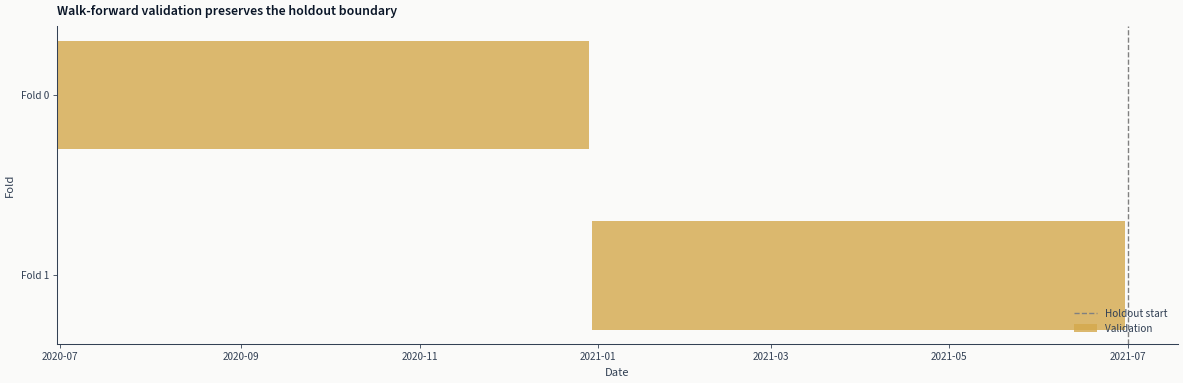

In [10]:
if best_preds.height > 0 and fold_ranges.height > 0:
    plot_cv_timeline(fold_ranges, n_splits, holdout_start)

Two walk-forward folds - `evaluation.n_splits` in `config/setup.yaml`, each
given `val_size: 6M` - and the evidence they carry is thin along one axis and
not the other. Reading either number as the other is the mistake this cell
exists to prevent.

**Scored rows are plentiful.** A prediction set is scored on the minute panel,
so a fold holds on the order of a hundred trading days at a few hundred scored
minutes each, across 113 symbols: millions of rows. How far each family got
across those days is what the scored-day coverage table above prints, per
family, and it is the number that decides whether two families are comparable -
not a row count, which a family can inflate by covering fewer days of a wider
cross-section.

**Decisions are far fewer than scored rows, and fewer than the row count
suggests.** `resolve_decision_schedule` thins the panel to the cadence
`decision.cadence_by_label` declares for this label - fifteen minutes, resolved
on the clock rather than by counting rows - so a day carries about twenty
decisions and not a few hundred. A model is scored on every minute it can
score; the strategy acts on one bar in fifteen.

**Regimes are what two folds cannot buy, and no sample size substitutes.** Both
folds fall inside 2020-2021, ending where `evaluation.holdout_start` begins on
2021-07-01: COVID recovery, meme-stock volatility and an unprecedented retail
trading surge. The rows inside a fold are not independent draws from the
regimes this strategy will meet, so millions of them buy precision within this
period and say nothing about the next one.

## 2. What Was Actually Run?

Before comparing results, map what is comparable. Not every model family was
trained on every label, and the modelling chapters produce different kinds of
evidence: predictive forecasts, latent structure, and estimated causal effects.
Each kind is ranked against its own kind, and the map below records which is
which.

In [11]:
# Coverage map: family × label × evidence type
EVIDENCE_TYPE = {
    "linear": "predictive",
    "gbm": "predictive",
    "tabular_dl": "predictive",
    "deep_learning": "predictive",
    "latent_factors": "structural",
    "causal_dml": "causal",
}
FAMILY_CHAPTER = {
    "linear": "Ch11",
    "gbm": "Ch12",
    "tabular_dl": "Ch12",
    "deep_learning": "Ch13",
    "latent_factors": "Ch14",
    "causal_dml": "Ch15",
}

coverage = (
    all_labels_metrics.group_by(["family", "label"])
    .agg(
        pl.col("config_name").n_unique().alias("n_configs"),
        pl.col("ic_mean").max().alias("best_ic"),
    )
    .with_columns(
        chapter=pl.col("family").replace(FAMILY_CHAPTER),
        evidence=pl.col("family").replace(EVIDENCE_TYPE),
    )
    .sort(["family", "label"])
)

print("Coverage Map: Families × Labels")
print(coverage.select(["chapter", "family", "label", "evidence", "n_configs", "best_ic"]))

Coverage Map: Families × Labels
shape: (14, 6)
┌──────────┬───────────────┬─────────────┬────────────┬───────────┬──────────┐
│ chapter  ┆ family        ┆ label       ┆ evidence   ┆ n_configs ┆ best_ic  │
│ ---      ┆ ---           ┆ ---         ┆ ---        ┆ ---       ┆ ---      │
│ str      ┆ str           ┆ str         ┆ str        ┆ u32       ┆ f64      │
╞══════════╪═══════════════╪═════════════╪════════════╪═══════════╪══════════╡
│ Ch13     ┆ deep_learning ┆ fwd_ret_15m ┆ predictive ┆ 4         ┆ 0.006563 │
│ Ch13     ┆ deep_learning ┆ fwd_ret_5m  ┆ predictive ┆ 3         ┆ 0.003526 │
│ Ch13     ┆ deep_learning ┆ fwd_ret_60m ┆ predictive ┆ 4         ┆ 0.004042 │
│ ensemble ┆ ensemble      ┆ fwd_ret_15m ┆ ensemble   ┆ 1         ┆ 0.007749 │
│ ensemble ┆ ensemble      ┆ fwd_ret_5m  ┆ ensemble   ┆ 1         ┆ 0.011924 │
│ …        ┆ …             ┆ …           ┆ …          ┆ …         ┆ …        │
│ Ch12     ┆ gbm           ┆ fwd_ret_60m ┆ predictive ┆ 15        ┆ 0.008806 │
│ Ch1

In [12]:
# Primary label coverage summary
primary_coverage = coverage.filter(pl.col("label") == PRIMARY_LABEL)
predictive_families = primary_coverage.filter(pl.col("evidence") == "predictive")[
    "family"
].to_list()
structural_families = primary_coverage.filter(pl.col("evidence") == "structural")[
    "family"
].to_list()
causal_families = primary_coverage.filter(pl.col("evidence") == "causal")["family"].to_list()
all_labels = sorted(coverage["label"].unique().to_list())

print(f"\nPrimary label ({PRIMARY_LABEL}):")
print(f"  Predictive families: {predictive_families}")
print(f"  Structural families: {structural_families or 'none'}")
print(f"  Causal families: {causal_families or 'none'}")
print(f"\nAll labels trained: {all_labels}")


Primary label (fwd_ret_15m):
  Predictive families: ['deep_learning', 'gbm', 'linear']
  Structural families: none
  Causal families: none

All labels trained: ['fwd_dir_15m', 'fwd_ret_15m', 'fwd_ret_5m', 'fwd_ret_60m']


Three predictive families were trained on the primary label - `linear`, `gbm`
and `deep_learning` - alongside the synthetic `ensemble` built from them, and
the causal estimate `12_causal_dml` registers separately because it is an
effect rather than an ordering. The coverage map above is the authority on
which families and labels a given run holds; this paragraph says what the
design intended, and the two are worth comparing rather than assuming equal.

Two of the expected families are absent by design. Latent factor models (Ch14)
were not trained: microstructure features at fifteen-minute frequency do not
carry the cross-sectional variation in fundamentals that factor models are
built to decompose. `tabular_dl` was not trained either, and the coverage
warning names both.

Four labels were explored: the primary `fwd_ret_15m`, a directional variant
(`fwd_dir_15m`), a shorter horizon (`fwd_ret_5m`) and a longer one
(`fwd_ret_60m`). The two return variants carry the same families as the primary
label; `fwd_dir_15m` carries only `linear` and `gbm`, which is what a
classification variant of the primary label needs to answer the question it is
asked. All cross-family comparisons use the primary label.

## 3. Headline Comparative View

Before comparing model families, we establish a baseline. If the
simplest possible model - linear regression on 66 microstructure
features - produces zero or negative IC, the prediction problem
is fundamentally too noisy at this frequency.

In [13]:
# Linear baseline
linear_metrics = all_metrics.filter(pl.col("family") == "linear")
if linear_metrics.height > 0:
    for name in ["ols", "ridge_a0.001", "ridge_a0.01", "ridge", "linear"]:
        baseline = linear_metrics.filter(pl.col("config_name") == name)
        if baseline.height > 0:
            ic = baseline["ic_mean"][0]
            std = baseline["ic_std"][0] if baseline["ic_std"][0] is not None else 0
            print(f"Linear baseline ({name}):")
            print(f"  IC mean:  {ic:+.4f}" if ic is not None else "  IC mean:  n/a")
            if std > 0:
                print(f"  IC std:   {std:.4f}")
                if ic is not None:
                    t_stat = ic / (std / np.sqrt(n_splits))
                    print(f"  t-stat:   {t_stat:.1f} (across {n_splits} folds)")
                else:
                    print("  t-stat:   n/a")
            break

Linear baseline (ols):
  IC mean:  +0.0008
  IC std:   0.0033
  t-stat:   0.3 (across 2 folds)


In [14]:
# Full ranking (top 15)
print(f"\nFull ranking ({all_metrics.height} model × checkpoint variants):")
print(
    all_metrics.head(15).select(["family", "config_name", "checkpoint_value", "ic_mean", "ic_std"])
)


Full ranking (243 model × checkpoint variants):
shape: (15, 5)
┌───────────────┬────────────────┬──────────────────┬───────────┬──────────┐
│ family        ┆ config_name    ┆ checkpoint_value ┆ ic_mean   ┆ ic_std   │
│ ---           ┆ ---            ┆ ---              ┆ ---       ┆ ---      │
│ str           ┆ str            ┆ i64              ┆ f64       ┆ f64      │
╞═══════════════╪════════════════╪══════════════════╪═══════════╪══════════╡
│ deep_learning ┆ nlinear        ┆ 55               ┆ 0.000531  ┆ 0.000782 │
│ deep_learning ┆ tcn            ┆ 65               ┆ 0.000691  ┆ 0.00066  │
│ gbm           ┆ leaves_7_mse   ┆ 350              ┆ 0.005898  ┆ 0.001094 │
│ deep_learning ┆ patchtst       ┆ 45               ┆ -0.002203 ┆ 0.002564 │
│ gbm           ┆ default_mse    ┆ 100              ┆ 0.004951  ┆ 0.002552 │
│ …             ┆ …              ┆ …                ┆ …         ┆ …        │
│ deep_learning ┆ tcn            ┆ 90               ┆ 0.000997  ┆ 0.00052  │
│ deep_learn

**How to read a rank correlation this small.** A cross-sectional rank
correlation is the correlation between the predicted ordering of stocks at one
decision time and their realised ordering. A value near zero means the model
gets barely more pairwise comparisons right than chance would.

The reason such a value is reported at all rather than dismissed is that the
ordering is acted on repeatedly. Under the Fundamental Law of Active
Management, an information ratio scales as the correlation times the square
root of the number of independent bets, so a correlation that is negligible on
one bar can accumulate over a year of bars. The condition in that sentence is
where the difficulty lies: consecutive 15-minute decisions on the same names
are not independent bets, so the square-root term overstates what is available,
and the multiplication says nothing about whether the trades survive their
costs.

Read each family's interval alongside its point estimate. Where two intervals
overlap, the evidence does not separate those families, whatever the ordering
of the point estimates.

With two folds, a statistic computed across fold-level scores has almost no
degrees of freedom. The intervals here use the per-day score as the unit of
analysis instead, which is why they are the reading to rely on.

Causal DML is not in this ranking. It lives in the `causal_runs` table and
reports an average treatment effect rather than a correlation.

### How much signal does each family extract?

The comparison uses each family's representative and looks at consistency
across folds as well as the average. With two folds that is a weak check, but
it catches the case that matters most: a representative whose score changes
sign between folds has not established a stable relationship at all.

In [15]:
# Build fold × family IC matrix - prefer registry fast path
if fold_metrics.height > 0:
    # Fast path: use per-fold IC from registry (no raw predictions needed)
    best_keys = best_per_family.select(["family", "config_name", "checkpoint_value"])
    fold_ic_parts = []
    for row in best_keys.iter_rows(named=True):
        mask = (pl.col("family") == row["family"]) & (pl.col("config_name") == row["config_name"])
        cp = row.get("checkpoint_value")
        if cp is not None:
            mask = mask & (pl.col("checkpoint_value") == cp)
        else:
            mask = mask & pl.col("checkpoint_value").is_null()
        part = fold_metrics.filter(mask)
        if part.height > 0:
            model_label = f"{row['family']}/{row['config_name']}"
            ic_col = "ic" if "ic" in part.columns else "ic_mean"
            fold_ic_parts.append(
                part.select(
                    pl.lit(model_label).alias("model_label"),
                    pl.col("fold_id"),
                    pl.col(ic_col).alias("ic_mean"),
                )
            )
    fold_ic = pl.concat(fold_ic_parts) if fold_ic_parts else pl.DataFrame()
else:
    # Slow path: compute from raw predictions
    fold_ic = (
        fold_performance_matrix(best_preds, date_col=DATE_COL)
        if best_preds.height > 0
        else pl.DataFrame()
    )

### Figure 2: Fold-by-Model Performance Heatmap

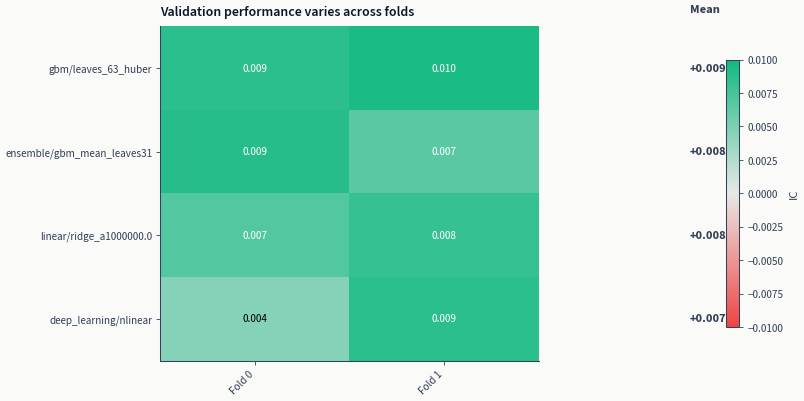

In [16]:
model_labels, fold_cols, matrix = plot_fold_heatmap(fold_ic)

In [17]:
# Summary statistics per family
if fold_ic.height > 0:
    family_stats = (
        fold_ic.group_by("model_label")
        .agg(
            pl.col("ic_mean").mean().alias("mean_ic"),
            pl.col("ic_mean").median().alias("median_ic"),
            pl.col("ic_mean").std().alias("std_ic"),
            pl.col("ic_mean").min().alias("worst_fold"),
            pl.col("ic_mean").max().alias("best_fold"),
            (pl.col("ic_mean") > 0).mean().alias("pct_positive"),
            pl.col("ic_mean").count().alias("n_folds"),
        )
        .sort("mean_ic", descending=True)
    )
    print("Family performance summary:")
    print(family_stats)

Family performance summary:
shape: (4, 8)
┌──────────────┬──────────┬───────────┬──────────┬────────────┬───────────┬──────────────┬─────────┐
│ model_label  ┆ mean_ic  ┆ median_ic ┆ std_ic   ┆ worst_fold ┆ best_fold ┆ pct_positive ┆ n_folds │
│ ---          ┆ ---      ┆ ---       ┆ ---      ┆ ---        ┆ ---       ┆ ---          ┆ ---     │
│ str          ┆ f64      ┆ f64       ┆ f64      ┆ f64        ┆ f64       ┆ f64          ┆ u32     │
╞══════════════╪══════════╪═══════════╪══════════╪════════════╪═══════════╪══════════════╪═════════╡
│ gbm/leaves_6 ┆ 0.009085 ┆ 0.009085  ┆ 0.000609 ┆ 0.008655   ┆ 0.009516  ┆ 1.0          ┆ 2       │
│ 3_huber      ┆          ┆           ┆          ┆            ┆           ┆              ┆         │
│ ensemble/gbm ┆ 0.00775  ┆ 0.00775   ┆ 0.00174  ┆ 0.00652    ┆ 0.00898   ┆ 1.0          ┆ 2       │
│ _mean_leaves ┆          ┆           ┆          ┆            ┆           ┆              ┆         │
│ 31           ┆          ┆           ┆          

**How to read the heatmap.** Each row is a model family, each column a fold,
and the shading is that family's representative's score on that fold. Three
things are worth checking in it, in order.

First, sign consistency across folds. A representative that is positive on one
fold and negative on the other has not shown a stable relationship, whatever
its average.

Second, the spread within a row against the spread between rows. When the
variation across folds is as large as the variation across families, the
ranking between families is being read off noise.

Third, which families are absent. A family with no tile was not trained for
this case study rather than trained and found wanting, and the two are not the
same conclusion. The coverage map above records which is which.

With two folds, none of this supports a fold-level stability claim. It is a
check for the obvious failure - a representative that does not hold its sign -
rather than a measurement of consistency.

## 4. Stability Over Time

With only 2 walk-forward folds, the stability analysis is inherently
limited. We cannot compute meaningful interquartile ranges or detect
bimodal distributions. Instead, we focus on whether the two folds
agree on the family ranking and whether either fold is negative.

### Figure 3: Fold Performance Distribution by Model Family

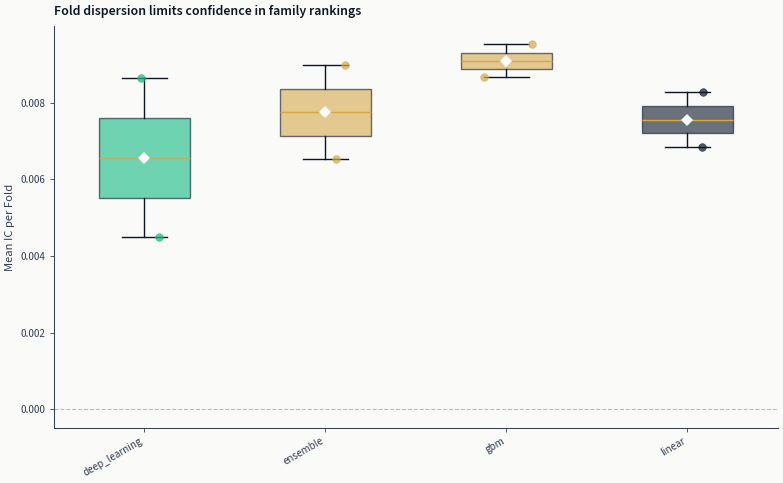

In [18]:
plot_fold_boxplot(fold_ic)

With only 2 data points per family, the box plots reduce to line segments connecting
the two fold ICs. Which configuration stands for each family is printed by the
representative table in section 1 and is not named here: it is the family's
highest-IC config on this label, so it moves when the models are refitted.

What to read off the segments is the sign, not the magnitude. A family positive in
both folds has at least not contradicted itself; one that crosses zero has, and two
folds cannot say which side is the accident. The **HAC-based per-day CIs in §3 and
§6** are the stronger evidence either way, because they pool over many days rather
than two blocks - and where those CIs overlap across families, the ordering of the
segments is not evidence that one family beat another.

**The 2-fold limitation is severe.** With 8 folds (as in the ETF
case study), we could distinguish "reliable but modest" from "noisy
but occasionally brilliant." With 2 folds, fold-level conclusions
about stability are descriptive only. All downstream judgments rely
on per-day HAC CIs (§3, §6), conformal calibration (§7), and the
causal robustness check (§7).

## 5. What Are the Models Learning?

Beyond aggregate IC, we examine the *structure* of predictions. Two
diagnostic questions matter:

1. **Monotonicity**: do higher predicted scores correspond to higher
   realized 15-minute returns? A monotonic relationship confirms
   ranking ability.
2. **Diversity**: do different model families produce similar or
   different rankings? At 15-minute frequency, where signal is weak,
   ensemble diversity is especially valuable.

In [19]:
# Compute prediction bucket monotonicity for best model per family
bucket_results = {}
for row in best_per_family.iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    checkpoint = row.get("checkpoint_value")

    mask = (pl.col("family") == family) & (pl.col("config_name") == config)
    if checkpoint is not None:
        mask = mask & (pl.col("checkpoint_value") == checkpoint)

    model_preds = best_preds.filter(mask) if best_preds.height > 0 else pl.DataFrame()
    if model_preds.height == 0:
        continue

    buckets = prediction_bucket_monotonicity(model_preds, N_BUCKETS, DATE_COL)
    if buckets.height > 0:
        bucket_results[family] = buckets

### Figure 4: Prediction Bucket Monotonicity

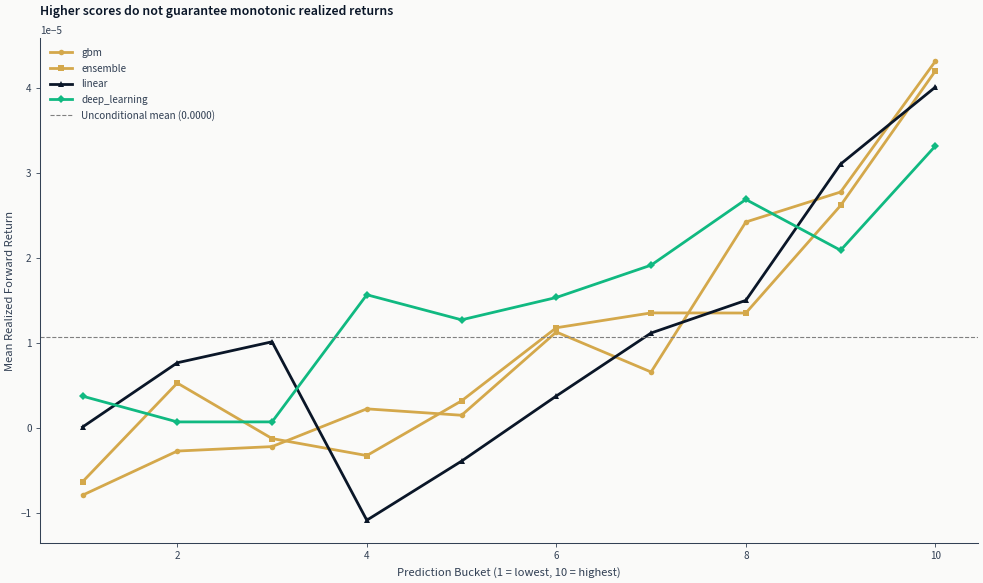


Top-bottom bucket spread vs trading costs (1–5 bps per leg):
  gbm                   spread=+1 bps  edge/cost=0.3–0.1x
  ensemble              spread=+0 bps  edge/cost=0.2–0.0x
  linear                spread=+0 bps  edge/cost=0.2–0.0x
  deep_learning         spread=+0 bps  edge/cost=0.1–0.0x


In [20]:
unconditional_mean = float(best_preds["y_true"].mean()) if best_preds.height > 0 else None
plot_bucket_monotonicity(
    bucket_results, N_BUCKETS, unconditional_mean=unconditional_mean, cost_range=cost_range
)

Read the monotonicity plot for whether the buckets are ordered at all, and the spreads
beneath it for whether that ordering is worth trading. The two are separate questions:
a signal can rank correctly and still move prices less per bar than a round trip costs,
which on this case study is the ordinary case rather than the failure case.

The bars show each family's representative at the primary label - the same
configurations section 1 printed - and their magnitudes come from the helper rather
than from this cell, so the prose cannot drift from the figure.

**The edge-to-cost ratios are all below 1.** The per-bar decile spread cannot
survive a single round-trip at any reasonable cost assumption: a round trip of
2 to 10 bps swamps it.

The annualized view is what keeps the question open, because the spread
compounds over the decision grid and the cost is charged per trade. A full
session carries 20 decision slots, not the 26 a 9:30-to-16:00 grid would give -
`resolve_decision_schedule` puts the label's fifteen-minute cadence on the
clock, and the scored window runs 10:31 to 15:43 - over about 253 sessions a
year. A selective strategy, trading only the most extreme signals and only in
the regime that favours them, can compound the spread while paying the cost on
a fraction of those slots.

The requirement this puts on the strategy is a rule for declining slots. The
edge per slot is what it is; what a design can change is how many slots it pays
for. Chapter 16's slot mechanism is where this case study makes that concrete.

In [21]:
# Pairwise prediction correlations
corr_matrix, corr_labels = (
    prediction_correlation_matrix(best_preds, date_col=DATE_COL, entity_col=ENTITY_COL)
    if best_preds.height > 0
    else (np.array([]), [])
)

### Figure 5: Prediction Correlation Across Models

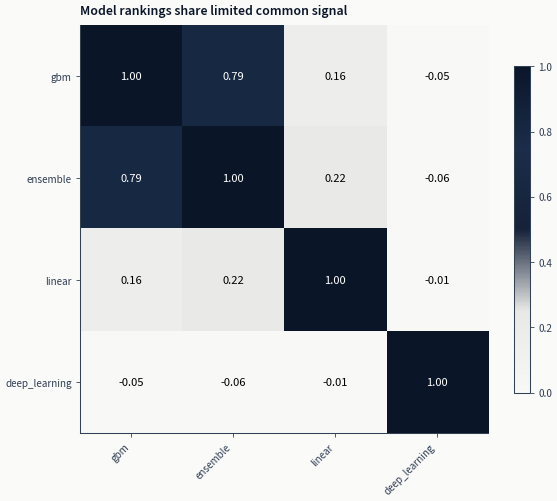


Average pairwise correlation: 0.18
Range: -0.06 to 0.79


In [22]:
plot_correlation_matrix(corr_matrix, corr_labels)

**How to read the correlation matrix.** Each cell is the correlation between
two families' representative predictions over the same rows. It answers a
question the scores cannot: whether two models that rank comparably well are
ranking the same way.

High correlation between families means they have found the same structure,
and combining them adds little. Low correlation means they are reading
different things from the same features, and a combination could be steadier
than either alone even when neither is stronger.

Low correlation is not by itself good news. Two models can disagree because
each is fitting a different part of the noise, which looks identical in this
matrix to two models capturing genuinely different structure. What separates
the cases is whether both hold their ordering out of sample, which is what the
fold view and the intervals address.

Causal DML is absent here by construction: it produces an effect estimate, not
a per-row prediction to correlate.

### How much does additional model complexity help?

For models that recorded checkpoints, the curve shows how the validation score
evolves as training proceeds. A curve that rises and then falls locates the
point past which the extra capacity is fitting noise. Row count is no
protection here: many rows of a weak, heavily overlapping signal still let a
flexible model memorise the noise.

In [23]:
# Learning curves from pre-computed metrics (fast path)
cp_data = all_metrics.filter(pl.col("checkpoint_value").is_not_null())
cp_families = (
    cp_data.group_by("family")
    .agg(pl.col("checkpoint_value").n_unique().alias("n_cp"))
    .filter(pl.col("n_cp") > 1)["family"]
    .to_list()
    if cp_data.height > 0
    else []
)

print(f"Families with checkpoint data: {cp_families}")

Families with checkpoint data: ['deep_learning', 'gbm']


### Figure 6: Learning Curves

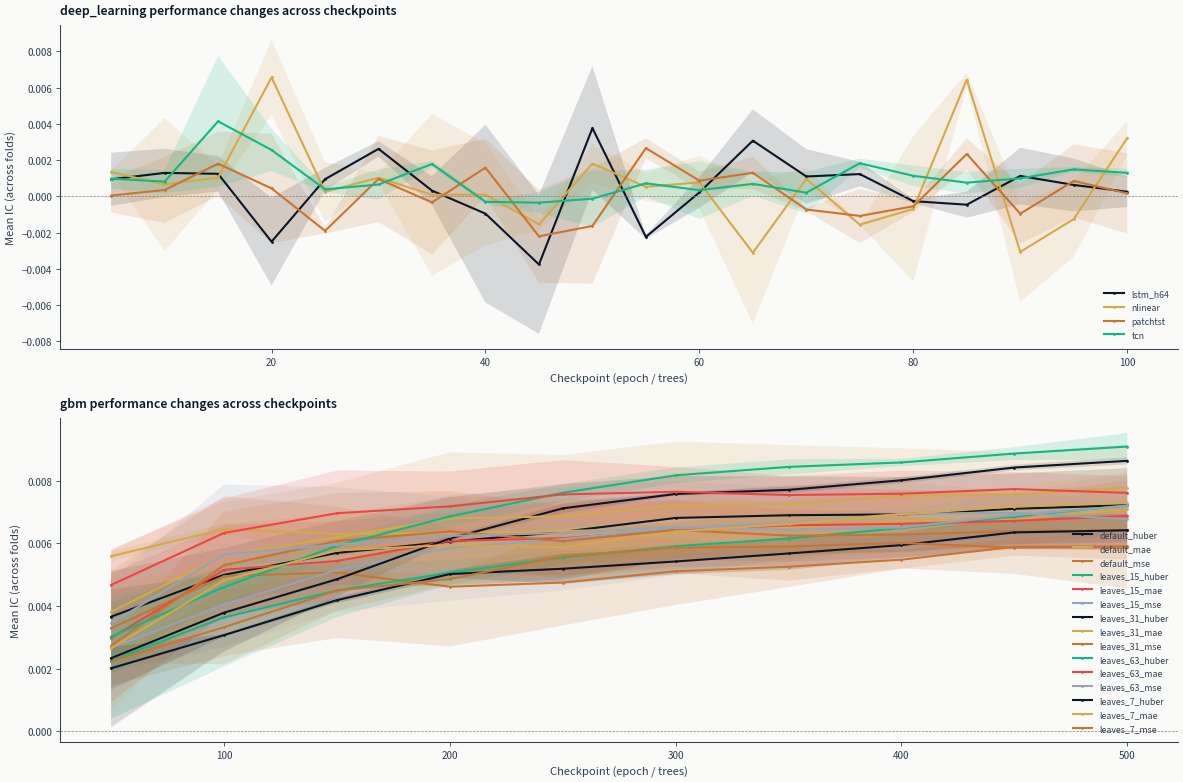

In [24]:
plot_learning_curves(cp_data, cp_families)

In [25]:
# Capacity against accuracy, computed rather than asserted. The GBM grid sweeps
# `num_leaves` over 7, 15, 31 and 63 crossed with three losses, so the question "does
# more capacity help on this panel" has an answer in the registry and does not need to
# be argued from the winner's name. Both columns are reported because they can
# disagree: the maximum is the best draw from a sample and grows with the number of
# scored candidates at that leaf count, while the mean describes the setting. Each row
# of `all_metrics` is one config-checkpoint pair, so `n_scored` - not `n_configs` - is
# the sample the maximum is drawn from.
_gbm = all_metrics.filter(pl.col("family") == "gbm")
_leaf_summary = (
    _gbm.with_columns(
        pl.col("config_name").str.extract(r"leaves_(\d+)", 1).cast(pl.Int64).alias("num_leaves")
    )
    .drop_nulls("num_leaves")
    .group_by("num_leaves")
    .agg(
        n_configs=pl.col("config_name").n_unique(),
        n_checkpoints=pl.col("checkpoint_value").n_unique(),
        n_scored=pl.len(),
        best_ic=pl.col("ic_mean").max(),
        mean_ic=pl.col("ic_mean").mean(),
    )
    .sort("num_leaves")
)
if _leaf_summary.height:
    print("GBM leaf count against IC on the primary label:")
    print(_leaf_summary)
else:
    print("No GBM configs carrying a leaf count in their name; capacity read skipped.")

GBM leaf count against IC on the primary label:
shape: (4, 6)
┌────────────┬───────────┬───────────────┬──────────┬──────────┬──────────┐
│ num_leaves ┆ n_configs ┆ n_checkpoints ┆ n_scored ┆ best_ic  ┆ mean_ic  │
│ ---        ┆ ---       ┆ ---           ┆ ---      ┆ ---      ┆ ---      │
│ i64        ┆ u32       ┆ u32           ┆ u32      ┆ f64      ┆ f64      │
╞════════════╪═══════════╪═══════════════╪══════════╪══════════╪══════════╡
│ 7          ┆ 3         ┆ 10            ┆ 30       ┆ 0.007293 ┆ 0.00529  │
│ 15         ┆ 3         ┆ 10            ┆ 30       ┆ 0.00721  ┆ 0.005675 │
│ 31         ┆ 3         ┆ 10            ┆ 30       ┆ 0.00863  ┆ 0.006315 │
│ 63         ┆ 3         ┆ 10            ┆ 30       ┆ 0.009086 ┆ 0.00677  │
└────────────┴───────────┴───────────────┴──────────┴──────────┴──────────┘


The learning curves trace IC across training checkpoints for the families that emit
them, and the table above asks the question the curves cannot: whether capacity helps
at all on this panel.

**Read the mean column and the best column against each other.** They answer different
questions. If mean IC rises with leaf count, more capacity helps the setting; if only
the maximum rises, the wider leaf counts may simply have had more scored candidates to
draw a maximum from. Where they disagree, the mean is the one to believe, because the
maximum of a larger sample is larger whether or not the family has an edge - the same
argument §3 makes about family maxima. `n_scored` is the count that governs that
comparison; when it is equal across leaf counts, the maxima are drawn from samples of
the same size and the column is comparable on that axis.

Do not read either column as the binding principle for boosting in general. It is one
label, two folds and one panel, and each row pools twice over: the grid crosses leaf
count with a loss function, and every config contributes one row per training
checkpoint. A leaf-count cell therefore mixes losses that may not respond the same way
with checkpoints taken at different points in the same fit. `n_scored` is therefore
`n_configs` multiplied by the checkpoints each config emits, and the search behind the
maximum is that many times wider than the configuration count alone suggests.

**The ensemble this case study features does not take the winner of this table.**
`ensemble.max_num_leaves` in `config/setup.yaml` is 31, so the featured mean forecast
averages the 7-, 15- and 31-leaf members and leaves out the 63-leaf ones entirely. That
is not an oversight competing with the table above: the table ranks single
configurations on one validation sample, and an average of regularized members is a bet
that the family generalizes where the individual maximum does not. Chapter 16 is where
the two are compared on the same footing, out of sample.

`deep_learning/nlinear` is an architecturally near-linear sequence model rather than a
deep recurrent one, and its highest IC is a single-config result with no meaningful
epoch-versus-IC progression to compare across architectures.

What the curves themselves show - a monotone rise then a plateau, or a peak followed
by decline - is the overfitting question, and it is the shape rather than the level
that answers it.

### Which Features Drive the Forecasts?

Feature importance from a single model fit is anecdotal. With only
2 walk-forward folds, even "recurring" importance is a low bar.
We examine which of the 66 microstructure features consistently
drive predictions, looking for features that appear in the top 5
in both folds.

In [26]:
# Booster-based gain first; feature-prediction correlation only if the boosters are
# unreadable. The two are different quantities and the fallback is not a degraded
# version of the first: gain is how much a feature reduced the loss inside the fitted
# GBM trees, while the fallback is the rank correlation between a feature and the
# LINEAR model's score. They can disagree completely, and one variable holding either
# is how a figure captioned "feature importance" came to show the other. `IMPORTANCE_
# SOURCE` is carried into the figure title so the render says which one it drew.
gbm_importance = load_gbm_feature_importance(CASE_STUDY, label=PRIMARY_LABEL, top_n=TOP_N_FEATURES)
IMPORTANCE_SOURCE = "gbm_gain" if gbm_importance is not None else None

if gbm_importance is None:
    # Fallback: compute feature-prediction IC (correlation between each feature and y_score)
    print(
        "No readable GBM boosters. Falling back to feature-prediction correlation, which is a "
        "different quantity - see the note above and read the figure title."
    )

    features_path = CASE_DIR / "features" / "financial.parquet"
    if features_path.exists() and best_preds.height > 0:
        features_df = pl.read_parquet(features_path)
        feat_cols = [c for c in features_df.columns if c not in [DATE_COL, ENTITY_COL]]

        # Join best linear model predictions with features
        linear_preds = best_preds.filter(pl.col("family") == "linear")
        if linear_preds.height > 0:
            # Put both sides of the join on the predictions' own clock. The previous alignment
            # handled only a `Date` feature column, so it missed the two ways these frames
            # actually differ: the sequence path returns `us` where the panel is written at
            # another unit, and a pandas round-trip can drop the zone. Measured 2026-09-09 on
            # the smoke chain - predictions `datetime[us, UTC]`, features `datetime[us]` naive,
            # and the join raised rather than matching nothing, which was the good case.
            if features_df[DATE_COL].dtype == pl.Date:
                features_df = features_df.with_columns(pl.col(DATE_COL).cast(pl.Datetime("us")))
            features_df = align_join_clock(features_df, linear_preds.schema[DATE_COL], DATE_COL)
            merged = linear_preds.join(features_df, on=[DATE_COL, ENTITY_COL], how="inner")

            # Compute correlation of each feature with y_score per fold
            importance_rows = []
            for fold in sorted(merged["fold_id"].unique().drop_nulls().to_list()):
                fold_data = merged.filter(pl.col("fold_id") == fold)
                for feat in feat_cols:
                    vals = fold_data[[feat, "y_score"]].drop_nulls()
                    if vals.height > 50:
                        from scipy.stats import spearmanr

                        corr, _ = spearmanr(vals[feat].to_numpy(), vals["y_score"].to_numpy())
                        importance_rows.append(
                            {
                                "config_name": "linear",
                                "fold_id": int(fold),
                                "feature": feat,
                                "importance": abs(float(corr)),
                            }
                        )

            if importance_rows:
                gbm_importance = pl.DataFrame(importance_rows)
                # Normalize per fold
                gbm_importance = gbm_importance.with_columns(
                    (
                        pl.col("importance")
                        / pl.col("importance").max().over(["config_name", "fold_id"])
                    ).alias("importance_norm")
                )
                # Filter to top features
                top_features = (
                    gbm_importance.group_by("feature")
                    .agg(pl.col("importance_norm").mean().alias("mean_imp"))
                    .sort("mean_imp", descending=True)
                    .head(TOP_N_FEATURES)["feature"]
                    .to_list()
                )
                gbm_importance = gbm_importance.filter(pl.col("feature").is_in(top_features))
                IMPORTANCE_SOURCE = "linear_correlation"
                print(
                    f"Computed feature-prediction correlation for {len(top_features)} features across {merged['fold_id'].n_unique()} folds"
                )

_IMPORTANCE_TITLES = {
    "gbm_gain": "GBM gain: a small feature set stays important across folds",
    "linear_correlation": (
        "FALLBACK - linear model feature correlation, NOT GBM gain: "
        "which features move with the linear score"
    ),
}
if gbm_importance is not None and gbm_importance.height > 0:
    print(
        f"Feature importance ({IMPORTANCE_SOURCE}): {gbm_importance['feature'].n_unique()} "
        f"features × {gbm_importance['fold_id'].n_unique()} folds"
    )
else:
    print("Feature importance data not available.")

Feature importance (gbm_gain): 15 features × 2 folds


### Figure 7: Feature Importance Stability Heatmap

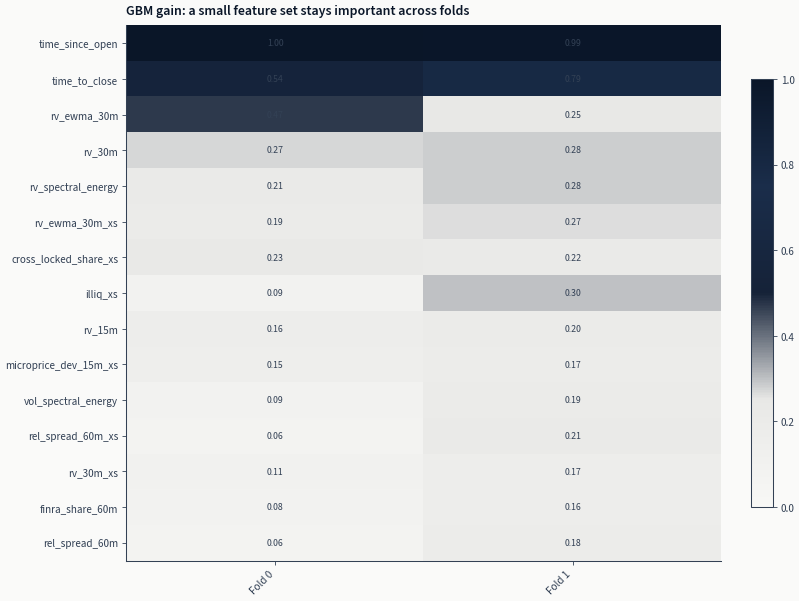


Persistent features (top-5 in ≥75% of folds): ['time_to_close', 'time_since_open', 'rv_30m']


In [27]:
plot_feature_importance_heatmap(
    gbm_importance,
    TOP_N_FEATURES,
    title=_IMPORTANCE_TITLES.get(IMPORTANCE_SOURCE, "Feature importance across folds"),
)

**What the heatmap is showing, and what it is not.** Gain-based importance says how
much a feature reduced the loss inside the fitted trees. It is not a causal statement
and it is not a ranking of forecasting power: two correlated features split the gain
between them, so a feature can matter and still read low because a near-copy of it
absorbed the credit. Read it for which features the models leaned on, and read
persistence across folds rather than the level in either one.

**Time of day dominates, and the form it takes is the finding.** The panel offers both
a continuous position in the session (`time_since_open`, `time_to_close`) and binary
bucket indicators (`is_first_30m`, `is_last_30m`). The models use the continuous pair
heavily and the indicators barely at all. A bucket says only whether the bar is inside
a named window; a continuous position lets a tree place a split anywhere in the
session and keep refining, which is what a boosted ensemble is built to exploit.

That the opening and closing minutes have their own microstructure is well established
- overnight information being incorporated into wider spreads and concentrated volume
at the open, rebalancing and MOC flow at the close. What this figure adds is that the
models did not need the buckets to use it.

The order-flow and liquidity features appear in the heatmap without persisting across
both folds, which is the diffuse-signal reading: no single microstructure feature
carries the bulk of the gain, and which of them surfaces shifts with the window.
This suggests the signal is diffuse: no single microstructure
feature carries the bulk of the signal, but the time-of-day context conditions which
features matter. The models may be implicitly learning "at the
open, order flow imbalance matters; at the close, spread dynamics
matter" - but with only 2 folds, we cannot confirm this.

## 6. Heterogeneity: Labels, Horizons, and Regimes

This section answers two questions: does the signal change across
prediction horizons? And does model ranking depend on the intraday
volatility regime? Both matter for strategy design at 15-minute
frequency.

### Multi-Label Comparison

Three regression labels span the horizon: a shorter horizon
(`fwd_ret_5m`), the primary `fwd_ret_15m`, and a longer horizon
(`fwd_ret_60m`). The classification variant `fwd_dir_15m` is scored on
different measures and is excluded from the forest below, which reports each
family's representative and its interval per label. Tiles marked as having no
run make coverage gaps visible rather than leaving them as absences.

In [28]:
multi_rows = []
for lbl in REGRESSION_LABELS:
    lbl_metrics = all_labels_metrics.filter(pl.col("label") == lbl)
    for fam in lbl_metrics["family"].unique().to_list():
        fam_data = lbl_metrics.filter(pl.col("family") == fam)
        rank1 = fam_data.sort("ic_mean_daily", descending=True, nulls_last=True).head(1)
        if rank1.height == 0:
            continue
        r = rank1.row(0, named=True)
        if r.get("ic_mean_daily") is None:
            continue
        multi_rows.append(
            {
                "label": lbl,
                "family": fam,
                "config_name": r["config_name"],
                "ic_mean_daily": r["ic_mean_daily"],
                "ic_ci_lo": r.get("ic_ci_lo"),
                "ic_ci_hi": r.get("ic_ci_hi"),
                "ic_t_hac": r.get("ic_t_hac"),
            }
        )

multi_label_df = pl.DataFrame(multi_rows)
multi_label_df

label,family,config_name,ic_mean_daily,ic_ci_lo,ic_ci_hi,ic_t_hac
str,str,str,f64,f64,f64,f64
"""fwd_ret_15m""","""deep_learning""","""nlinear""",0.006563,0.001864,0.011261,2.737523
"""fwd_ret_15m""","""gbm""","""leaves_63_huber""",0.009086,0.006181,0.011991,6.130082
"""fwd_ret_15m""","""linear""","""ridge_a1000000.0""",0.007555,0.004895,0.010215,5.567096
"""fwd_ret_15m""","""ensemble""","""gbm_mean_leaves31""",0.007749,0.004816,0.010681,5.178596
"""fwd_ret_5m""","""deep_learning""","""lstm_h64""",0.003526,0.001774,0.005278,3.944028
…,…,…,…,…,…,…
"""fwd_ret_5m""","""linear""","""ridge_a1000000.0""",0.011673,0.010217,0.01313,15.707681
"""fwd_ret_60m""","""gbm""","""leaves_63_mse""",0.008806,0.003737,0.013876,3.404674
"""fwd_ret_60m""","""linear""","""ridge_a1000000.0""",0.007782,0.00257,0.012994,2.926333


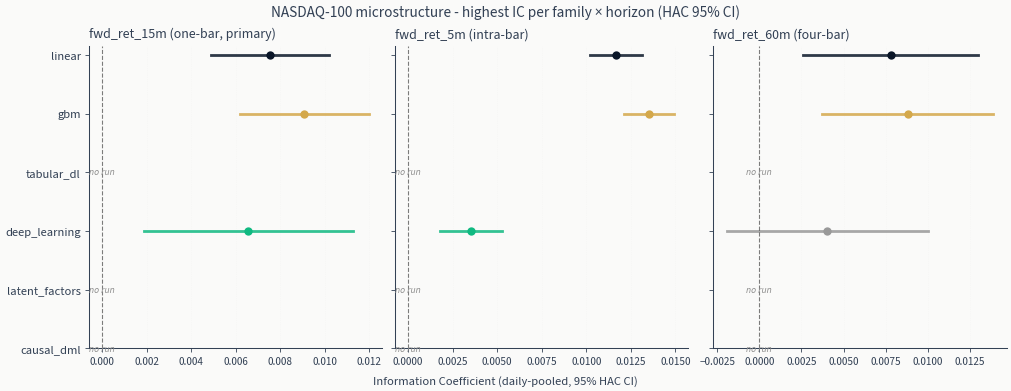

In [29]:
plot_label_horizon_forest(
    multi_label_df,
    families=["linear", "gbm", "tabular_dl", "deep_learning", "latent_factors", "causal_dml"],
    labels=REGRESSION_LABELS,
    label_display={
        "fwd_ret_5m": "fwd_ret_5m (intra-bar)",
        "fwd_ret_15m": "fwd_ret_15m (one-bar, primary)",
        "fwd_ret_60m": "fwd_ret_60m (four-bar)",
    },
    title="NASDAQ-100 microstructure - highest IC per family × horizon (HAC 95% CI)",
)

**How to read the horizon forest.** Each row is one family at one label
horizon, the marker is its representative's score and the bar is that score's
confidence interval. Three readings, in order of what they can support.

A bar that crosses zero means the sign of the relationship is not established
at that horizon. That is a stronger statement than a small point estimate, and
it is the first thing to check on every row.

Comparing rows *down* a family shows how the horizon changes what is
detectable. A shorter horizon puts less time between the prediction and the
outcome, so less unrelated movement accumulates in between, and the
relationship is usually easier to detect. That says nothing about whether it is
easier to *trade*: a shorter horizon means more rebalances and more crossings
of the spread, which is exactly the tension the cost notebook resolves.

Comparing rows *across* families at one horizon is the weakest of the three.
Where the intervals overlap, the families are not separated, and the ordering
of their markers should not be reported as a ranking.

A missing tile means the family was not trained at that horizon, which is not
the same as a family that was trained and scored poorly. The coverage map
records which families ran; `causal_dml` is absent by construction, since it
estimates an effect rather than an ordering.

### Regime Conditioning

The conditioning variable is cross-sectional dispersion: when the
cross-section spreads out, a ranking has more to rank and a microstructure
signal has more room to be right or wrong. `regime_conditional_ic` computes it
for each decision time as the standard deviation of realized returns across
the symbols quoting at that time, then splits the decision times at the median
into `high_vol` and `low_vol` and scores the rank IC within each half.

Two things follow from it being a median split of per-timestamp dispersion, and
both bound what the figure below can say. The halves are equal by construction,
so "half the decision times are high-volatility" is arithmetic and not a
finding. And the classification is per decision time rather than per day or per
episode, so adjacent bars can fall in opposite halves - this separates
dispersed cross-sections from tight ones, and does not identify a volatile
period that a strategy could recognise while it was in one.

The split is taken over the sampled grid loaded above, so it is the median of
the timestamps kept rather than of every timestamp scored.

In [30]:
# Compute regime-conditional IC
regime_results = []

for row in best_per_family.iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    checkpoint = row.get("checkpoint_value")

    mask = (pl.col("family") == family) & (pl.col("config_name") == config)
    if checkpoint is not None:
        mask = mask & (pl.col("checkpoint_value") == checkpoint)

    model_preds = best_preds.filter(mask) if best_preds.height > 0 else pl.DataFrame()
    if model_preds.height == 0:
        continue

    regime_ic = regime_conditional_ic(model_preds, date_col=DATE_COL)
    if regime_ic.height > 0:
        regime_ic = regime_ic.with_columns(pl.lit(family).alias("family"))
        regime_results.append(regime_ic)

regime_df = pl.concat(regime_results) if regime_results else pl.DataFrame()

### Figure 8: Conditional Performance by Volatility Regime

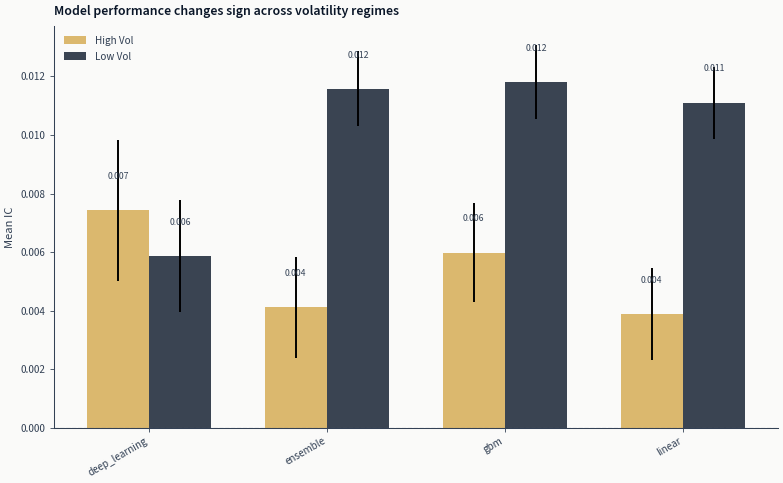

In [31]:
plot_regime_bars(regime_df)

Regime sensitivity is critical for intraday microstructure strategies.
During high-volatility periods (large cross-sectional dispersion),
microstructure signals are typically stronger: spreads widen, order
flow imbalances become more informative, and the cross-section
separates more sharply. During low-volatility periods, all stocks
move together and microstructure features provide less differentiation.

If the high-vol IC is significantly higher than low-vol IC for all
families, the strategy has a natural "when to trade" filter: reduce
positions during calm markets when the signal-to-noise ratio is
poorest. This regime conditioning could meaningfully improve the
net edge after costs by avoiding trades where the expected return
per bar is too low to cover the spread.

## 7. Structural and Causal Evidence

Not all model chapters produce comparable predictive scores. Ch14
(latent factors) extracts structure; Ch15 (causal DML) estimates
treatment effects. These require separate evidence blocks.

### Latent Factors (Ch14)

Latent factor models were **not trained** for the NASDAQ-100
microstructure case study. At 15-minute frequency, the cross-section
of 113 stocks lacks the fundamental heterogeneity that factor models
require - these are all large-cap US tech stocks with highly
correlated microstructure dynamics. PCA or CAE applied to intraday
microstructure features would extract market-wide volatility modes,
not tradeable cross-sectional factors.

This contrasts with the broader panels elsewhere in the book. US Firm
Characteristics declares `universe.n_assets: 2500` and SP500 Equity+Options
declares 633, against the 115 this case study declares and the 113 that carry
prices and predictions. Those are declarations from each case study's
`config/setup.yaml` and not counts realized by a run, which is the reason to
read them as an order of magnitude: a cross-section twenty times wider is what
gives a latent factor something to vary across.

### Causal DML (Ch15)

Causal results live in a dedicated `causal_runs` table (separate
from `prediction_metrics`). Causal DML estimates an **average
treatment effect** of a microstructure treatment on next-bar
returns, with HAC-robust standard errors and a refutation test.
It does not produce a per-asset cross-sectional score, so it is
reported as ATE/SE/p_HAC rather than IC.

Treatment: `signed_vol_share` (signed volume share at the bar); confounders:
`rel_spread_close`, `rv_5m`, `r1m`. The embargo is **16 periods**, which on this
one-minute panel is sixteen minutes: it follows `labels.buffer` (`16min`) and not the
treatment's own construction window, which is one bar. `causal_runs.embargo` records
what the run used, and `12_causal_dml` is where the choice is argued.

In [32]:
# `causal_runs` is keyed on `causal_hash`, and that identity covers the fold and placebo
# geometry, the seed, the horizon, the row cap and the development cutoff - not the label.
# Re-running the causal notebook under any different design therefore writes a *second* row
# for the same label rather than replacing the first, so `ORDER BY label` over the whole table
# lists two estimates with nothing to tell them apart. `CausalResult.one` resolves the single
# identity currently in force for a label and refuses on an ambiguous registry rather than
# picking, which is the read this section is about; the superseded rows are counted, not shown.
import sqlite3 as _sqlite3

DECLARED_LABELS = [PRIMARY_LABEL, *[lbl for lbl in REGRESSION_LABELS if lbl != PRIMARY_LABEL]]

with _sqlite3.connect(CASE_DIR / "run_log" / "registry.db") as _con:
    _recorded = _con.execute("SELECT count(*) FROM causal_runs").fetchone()[0]
    _attempted = {r[0] for r in _con.execute("SELECT DISTINCT label FROM causal_runs")}

_causal_rows = []
_unresolved = {}
for _label in [lbl for lbl in DECLARED_LABELS if lbl in _attempted]:
    try:
        _result = CausalResult.one(study, label=_label, execution_tier="canonical")
    except ValueError as _exc:
        _unresolved[_label] = str(_exc)
        continue
    _causal_rows.append(
        {
            "label": _label,
            "causal_hash": _result.hash[:12],
            "dml_effect": _result.metrics["dml_effect"],
            "dml_se_hac": _result.metrics["dml_se_hac"],
            "p_value_hac": _result.metrics["p_value_hac"],
            "naive_effect": _result.metrics["naive_effect"],
            "confounding_bias_pct": _result.metrics["confounding_bias_pct"],
            "refutation_p": _result.metrics["refutation_p"],
            "n_obs": _result.metrics["n_obs"],
        }
    )

causal_df = pl.DataFrame(_causal_rows).sort("label") if _causal_rows else pl.DataFrame()
print("Causal DML on signed_vol_share:")
print(f"labels carrying a current causal identity: {causal_df.height} of {len(_attempted)} run")
print(f"superseded rows also in the table: {_recorded - causal_df.height}")
print(causal_df)
for _label, _why in _unresolved.items():
    print(f"unresolved: {_label}: {_why}")

Causal DML on signed_vol_share:
labels carrying a current causal identity: 1 of 1 run
superseded rows also in the table: 0
shape: (1, 9)
┌────────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬─────────┐
│ label      ┆ causal_ha ┆ dml_effec ┆ dml_se_ha ┆ … ┆ naive_eff ┆ confoundi ┆ refutatio ┆ n_obs   │
│ ---        ┆ sh        ┆ t         ┆ c         ┆   ┆ ect       ┆ ng_bias_p ┆ n_p       ┆ ---     │
│ str        ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ct        ┆ ---       ┆ i64     │
│            ┆ str       ┆ f64       ┆ f64       ┆   ┆ f64       ┆ ---       ┆ f64       ┆         │
│            ┆           ┆           ┆           ┆   ┆           ┆ f64       ┆           ┆         │
╞════════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═════════╡
│ fwd_ret_15 ┆ fd720b976 ┆ -0.000008 ┆ 0.000006  ┆ … ┆ -0.00001  ┆ -15.39099 ┆ 1.0       ┆ 9953629 │
│ m          ┆ 65b       ┆           ┆           ┆   ┆ 

**How to read the causal rows.** Each row is an estimated average treatment
effect: how much the outcome moves per unit change in `signed_vol_share`, after
adjusting for the confounders. Four columns decide what the row supports.

The naive and adjusted effects together say what the adjustment did. If the
adjusted effect is smaller, the confounders were carrying part of the raw
association. If it is larger, they were masking it. Either direction is
informative; a large gap in either direction is a reason to look at the
nuisance models before trusting the result.

The Newey-West p-value and the permutation p-value answer different questions
and frequently disagree, as `12_causal_dml` explains in full. When they do,
the parametric one is the one to distrust.

**`refutation_p` is not yet a test this estimate can fail, and should not be read as a passing
check.** The permutation refutation shuffles the treatment within blocks, and the block has to be
at least as long as the autocorrelation the estimate rests on, or the shuffle destroys exactly
the structure the placebo is supposed to preserve. The block length is currently taken from the
label buffer rather than from the treatment's own window, and `signed_vol_share` declares no
window, so the block is not derived from the quantity it has to bound. A refutation built that
way passes by construction. `us_firm_characteristics` measured what that looks like on its own
treatment: the placebo distribution sat wholly above the observed effect, many standard
deviations away, so the refutation returned a p-value of one - a placebo distribution that
cannot contain the truth is not evidence about it.
Read the column as unresolved until the treatment declares its window.

The effect is measured per unit of the treatment, and treatment units are not
comparable across labels or case studies. An effect that looks microscopic in
absolute terms may or may not matter once multiplied by the spread of
`signed_vol_share` actually observed across stocks. The strategy notebooks
carry out that multiplication and add the costs of acting on it.

These rows are not comparable to the correlations above. They estimate the
effect of intervening on one feature; a rank correlation measures how well an
ordering of all features anticipates an ordering of returns.

### Calibration: Are Prediction Intervals Honest?

Point IC tells us whether the ranking is correct on average; it says
nothing about whether the model's *uncertainty* is well calibrated. The
width measured here is the one the `conformal_weighted` allocator sizes
positions with in the eight case studies that declare it. This one does not:
`backtest.sweep.allocators` here is `equal_weight`, `score_weighted` and
`inverse_vol`, so the diagnostic below describes the model and nothing
downstream consumes it. It is calibrated per symbol on every absolute
residual known at
`t - h`, where `h` is this label's horizon in data steps, falling back to a
quantile pooled over every symbol where one has too few residuals of its
own. A decision is covered when its absolute residual falls inside that
half-width, and `n_uncalibrated` counts the decisions that cleared no
warm-up and that no coverage figure describes.

Empirical coverage materially below the nominal level signals overconfident
residual scaling - the model is more wrong, more often, than its
training-time spread suggests. Width is reported as a fraction of the
standard deviation of the outcomes it was measured against, so families with
different return scales are comparable; smaller width at matched coverage
means tighter, more useful intervals.

Read it as a diagnostic of residual dispersion rather than a guarantee.
Split conformal's finite-sample coverage guarantee (Vovk et al., 2005; Lei et
al., 2018) requires the calibration and evaluation scores to be exchangeable,
and return residuals are not: they are serially dependent and their dispersion
moves with the regime, so the nominal level is a target the procedure aims at
here rather than one it attains. Where the allocator is swept, it reads the
width as a volatility estimate and never reads the coverage level, so a
miscalibrated interval reaches position sizing as a scale and not as a
probability. See Ch12 §12.6 / `12_gradient_boosting/11_conformal_gbm` for the
full conformal toolkit (CQR, ACI).

Each row is the family's highest-IC configuration for the primary label.
That is a model-level ranking and not the funnel's - every selection stage
ranks on validation backtest Sharpe - and it is used here because this
diagnostic runs before any backtest exists to rank.

In [33]:
conformal_df = conformal_coverage_diagnostic(CASE_STUDY, label=PRIMARY_LABEL)
conformal_df

case_studies/utils/conformal.py:515: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  targets.join_asof(


family,config_name,nominal_level,empirical_coverage,mean_interval_width_frac_std,n_test,n_uncalibrated
str,str,f64,f64,f64,i64,i64
"""deep_learning""","""nlinear""",0.8,0.818318,2.325812,6452412,1549
"""deep_learning""","""nlinear""",0.9,0.909064,3.161223,6452412,1549
"""deep_learning""","""nlinear""",0.95,0.953761,4.002886,6452412,1549
"""ensemble""","""gbm_mean_leaves31""",0.8,0.817031,2.283335,8005371,1624
"""ensemble""","""gbm_mean_leaves31""",0.9,0.90838,3.121367,8005371,1624
…,…,…,…,…,…,…
"""gbm""","""leaves_63_huber""",0.9,0.908467,3.125635,8005371,1624
"""gbm""","""leaves_63_huber""",0.95,0.953569,3.974726,8005371,1624
"""linear""","""ridge_a1000000.0""",0.8,0.817126,2.281512,8005371,1624


In [34]:
if conformal_df.height > 0:
    pivot = conformal_df.pivot(
        on="nominal_level",
        index=["family", "config_name"],
        values=["empirical_coverage", "mean_interval_width_frac_std"],
    )
    print("Empirical coverage and width (× std of returns) at 80/90/95% nominal:")
    print(pivot)

Empirical coverage and width (× std of returns) at 80/90/95% nominal:
shape: (4, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ family     ┆ config_nam ┆ empirical_ ┆ empirical ┆ empirical ┆ mean_inte ┆ mean_inte ┆ mean_inte │
│ ---        ┆ e          ┆ coverage_0 ┆ _coverage ┆ _coverage ┆ rval_widt ┆ rval_widt ┆ rval_widt │
│ str        ┆ ---        ┆ .8         ┆ _0.9      ┆ _0.95     ┆ h_frac_st ┆ h_frac_st ┆ h_frac_st │
│            ┆ str        ┆ ---        ┆ ---       ┆ ---       ┆ d_0…      ┆ d_0…      ┆ d_0…      │
│            ┆            ┆ f64        ┆ f64       ┆ f64       ┆ ---       ┆ ---       ┆ ---       │
│            ┆            ┆            ┆           ┆           ┆ f64       ┆ f64       ┆ f64       │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ deep_learn ┆ nlinear    ┆ 0.818318   ┆ 0.909064  ┆ 0.953761  ┆ 2.325812  ┆ 3.161223  ┆ 4.002886  │
│ ing  

**How to read the coverage table.** Two columns matter, and they fail
independently.

Empirical coverage against nominal is the calibration check. A width advertised
at a given confidence level should contain the realised residual about that often
across the decisions it sized. Coverage materially below nominal means the model is
confident more often than it is right; above nominal means the widths are wider
than they need to be.

**What that does and does not say about position sizes.** `conformal_weighted`
normalises `1/width` within each side at each timestamp, so a width scale that is
uniformly too small leaves every weight unchanged - the error divides out. Coverage
is a statement about the scale of the residuals, and only the *differences* between
symbols' widths reach the portfolio. A systematic shortfall therefore says the
uncertainty estimate is optimistic, not that any particular position was too large,
and nothing in this table tests whether the widths rank one symbol's risk against
another correctly. Read it as a residual-scale diagnostic.

Width per standard deviation says what that coverage cost. A width that reaches
nominal coverage only by spanning several standard deviations of the return
distribution is honest and says little. Read the two together as a description
of the residual scale: covered at what width. Neither column measures how the
widths differ across symbols, which is the only thing the allocator reads, so
neither settles whether a family can be sized on them.

A family can rank well and fail this badly. Ranking depends only on the order
of the predictions; coverage depends on the scale of a symbol's past residuals
carrying forward to the decision they size. A shortfall is consistent with
residual scale that does not hold out of time, and also with finite-sample
variation, with residuals that are not independent, and with symbols sized from
the pooled fallback rather than their own history - this table does not separate
them. It is a reason to look at the widths' cross-section before trusting them to
size, and it says nothing about the ordering, which is unaffected.

## 8. Pre-Backtest Judgment and Handoff

The synthesis below collects, per family, the evidence a backtest depends on:
the representative's score with its interval, its behaviour across folds, and
whether its intervals are calibrated. Two folds is little temporal evidence, so
the summary is a description of what was measured rather than a
recommendation.

In [35]:
synthesis_rows = []

for row in best_per_family.iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    ic_mean = row["ic_mean"]
    ic_std_val = row.get("ic_std") or 0

    label_key = f"{family}/{config}"
    fam_folds = (
        fold_ic.filter(pl.col("model_label") == label_key) if fold_ic.height > 0 else pl.DataFrame()
    )

    if fam_folds.height > 0:
        fold_ics = fam_folds["ic_mean"].to_numpy()
        median_ic = float(np.median(fold_ics))
        std_ic = float(np.std(fold_ics))
        pct_pos = float((fold_ics > 0).mean())
        worst = float(np.min(fold_ics))
    else:
        median_ic, std_ic, pct_pos, worst = (
            ic_mean,
            ic_std_val,
            (1.0 if ic_mean > 0 else 0.0),
            ic_mean,
        )

    spread = 0.0
    if family in bucket_results:
        b = bucket_results[family]
        if b.height >= 2:
            spread = (
                b.filter(pl.col("bucket") == N_BUCKETS)["mean_return"][0]
                - b.filter(pl.col("bucket") == 1)["mean_return"][0]
            )

    if median_ic > 0 and pct_pos > 0.6 and spread > 0:
        ci_tier = "excludes_zero_or_positive_pct>0.6"
    elif ic_mean > 0:
        ci_tier = "positive_mean_only"
    else:
        ci_tier = "below_credibility"

    synthesis_rows.append(
        {
            "family": family,
            "config": config,
            "ic_mean": round(ic_mean, 4),
            "ic_median": round(median_ic, 4),
            "ic_std": round(std_ic, 4),
            "pct_positive": round(pct_pos, 2),
            "worst_fold": round(worst, 4),
            "spread_bps": round(spread * 10000, 1),
            "ci_tier": ci_tier,
        }
    )

synthesis = pl.DataFrame(synthesis_rows).sort("ic_mean", descending=True)
print("Synthesis Table:")
print(synthesis)

Synthesis Table:
shape: (4, 9)
┌────────────┬───────────┬─────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ family     ┆ config    ┆ ic_mean ┆ ic_median ┆ … ┆ pct_posit ┆ worst_fol ┆ spread_bp ┆ ci_tier   │
│ ---        ┆ ---       ┆ ---     ┆ ---       ┆   ┆ ive       ┆ d         ┆ s         ┆ ---       │
│ str        ┆ str       ┆ f64     ┆ f64       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ str       │
│            ┆           ┆         ┆           ┆   ┆ f64       ┆ f64       ┆ f64       ┆           │
╞════════════╪═══════════╪═════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ gbm        ┆ leaves_63 ┆ 0.0091  ┆ 0.0091    ┆ … ┆ 1.0       ┆ 0.0087    ┆ 0.5       ┆ excludes_ │
│            ┆ _huber    ┆         ┆           ┆   ┆           ┆           ┆           ┆ zero_or_p │
│            ┆           ┆         ┆           ┆   ┆           ┆           ┆           ┆ ositive_p │
│            ┆           ┆         ┆           ┆   ┆        

### How to read the synthesis table

One row per family, collecting what the sections above measured separately:
the representative's score with its interval, its per-fold behaviour, its
decile bucket spread, and its interval calibration. Read across a row rather
than down a column, because a family is only usable when several of these hold
at once, and they fail independently.

Where intervals overlap between rows, those families are not separated by this
evidence, and the ordering of their point estimates should not be reported as a
ranking. With two folds, the per-fold columns are weak evidence about stability
and are there to expose a sign change rather than to measure consistency.

The calibration columns qualify a family that looks fine on score alone rather
than disqualifying it. A model whose widths do not hold their nominal coverage
can still be traded on its ordering; whether it can be sized on those widths is
a question the coverage columns do not answer, because `conformal_weighted`
consumes the cross-section of widths and coverage measures their scale. Measure
the cross-section before sizing on it.

Causal rows are reported separately and are never inserted into this table.
They estimate the effect of a feature rather than forecast a return.

### The decay question this table cannot answer

Every score here assumes the prediction made at one decision time is acted on
at the next. Between those two moments sit signal computation, portfolio
construction and order routing. If the relationship weakens over that interval,
the achievable version is smaller than the measured one, and at this horizon
there is little room for it to shrink before trading costs exceed it. Nothing
in a validation score measures that gap; a backtest that fills at the intended
time and one that fills a minute later do.

### Forecast Representation

For backtesting, predictions are used as:

- **Rank-based selection**: sort by score, take the top and bottom names at
  each decision time in equal measure, so the position is on the ordering
  rather than on the market's direction.
- **Regime filter**: trade only when the cross-section is dispersed enough for
  the ordering to be worth acting on. When predicted differences between names
  are smaller than the cost of switching between them, trading on the ordering
  loses money however correct it is.
- **Ensemble**: averaging families that disagree reduces the variance of the
  combined ordering. It adds nothing to the ordering's strength, and it is
  worth most as protection against one family being miscalibrated rather than
  as a source of edge.

### What This Analysis Does Not Tell Us

- **Execution feasibility**: 15-minute rebalancing across 113
  stocks requires institutional-grade execution infrastructure.
  The market impact of simultaneously trading the top and bottom
  deciles may exceed the predicted edge.
- **Signal decay**: we assumed next-bar execution. Any delay
  degrades performance geometrically.
- **Capacity**: even NASDAQ-100 stocks have limited intraday
  liquidity at the bar level. A \$10M strategy may face meaningful
  market impact; a \$100M strategy almost certainly would.
- **Survivorship bias**: the 115-stock universe was selected based
  on NASDAQ-100 membership, which is backward-looking.
- **2-fold limitation**: the strongest caveat. 2020--2021 was an
  extraordinary period (COVID, retail trading boom, meme stocks).
  Whether these patterns persist in normal markets is unknown.

**Next**: `14_backtest.py` for strategy simulation,
`15_portfolio_management.py` for position sizing, and
`20_strategy_analysis.py` for end-to-end results.

### What the comparison found on this run

The representative of each family at full coverage, on the primary label, with
its HAC interval; the same measure across the label horizons; and the causal
rows, which are effects rather than correlations and are not comparable to the
rows above.

In [36]:
_ci_cols = [c for c in ("ic_ci_lo", "ic_ci_hi") if c in best_per_family.columns]
print(f"Representative per family on {PRIMARY_LABEL} (full coverage only):")
print(best_per_family.select(["family", "config_name", "checkpoint_value", "ic_mean", *_ci_cols]))

Representative per family on fwd_ret_15m (full coverage only):
shape: (4, 6)
┌───────────────┬───────────────────┬──────────────────┬──────────┬──────────┬──────────┐
│ family        ┆ config_name       ┆ checkpoint_value ┆ ic_mean  ┆ ic_ci_lo ┆ ic_ci_hi │
│ ---           ┆ ---               ┆ ---              ┆ ---      ┆ ---      ┆ ---      │
│ str           ┆ str               ┆ i64              ┆ f64      ┆ f64      ┆ f64      │
╞═══════════════╪═══════════════════╪══════════════════╪══════════╪══════════╪══════════╡
│ gbm           ┆ leaves_63_huber   ┆ 500              ┆ 0.009086 ┆ 0.006181 ┆ 0.011991 │
│ ensemble      ┆ gbm_mean_leaves31 ┆ null             ┆ 0.007749 ┆ 0.004816 ┆ 0.010681 │
│ linear        ┆ ridge_a1000000.0  ┆ null             ┆ 0.007555 ┆ 0.004895 ┆ 0.010215 │
│ deep_learning ┆ nlinear           ┆ 20               ┆ 0.006563 ┆ 0.001864 ┆ 0.011261 │
└───────────────┴───────────────────┴──────────────────┴──────────┴──────────┴──────────┘


In [37]:
if "ic_n_days" in all_labels_metrics.columns:
    _horizon = (
        all_labels_metrics.filter(pl.col("family").is_in(["linear", "gbm", "deep_learning"]))
        .group_by(["label", "family"])
        .agg(pl.col("ic_mean").max().alias("highest_ic"), pl.len().alias("sets"))
        .sort(["family", "label"])
    )
    print("\nHighest registered score by label and family:")
    print(_horizon)


Highest registered score by label and family:
shape: (11, 4)
┌─────────────┬───────────────┬────────────┬──────┐
│ label       ┆ family        ┆ highest_ic ┆ sets │
│ ---         ┆ ---           ┆ ---        ┆ ---  │
│ str         ┆ str           ┆ f64        ┆ u32  │
╞═════════════╪═══════════════╪════════════╪══════╡
│ fwd_ret_15m ┆ deep_learning ┆ 0.006563   ┆ 80   │
│ fwd_ret_5m  ┆ deep_learning ┆ 0.003526   ┆ 60   │
│ fwd_ret_60m ┆ deep_learning ┆ 0.004042   ┆ 80   │
│ fwd_dir_15m ┆ gbm           ┆ 0.008297   ┆ 50   │
│ fwd_ret_15m ┆ gbm           ┆ 0.009086   ┆ 150  │
│ …           ┆ …             ┆ …          ┆ …    │
│ fwd_ret_60m ┆ gbm           ┆ 0.008806   ┆ 150  │
│ fwd_dir_15m ┆ linear        ┆ 0.009106   ┆ 13   │
│ fwd_ret_15m ┆ linear        ┆ 0.007555   ┆ 12   │
│ fwd_ret_5m  ┆ linear        ┆ 0.011673   ┆ 12   │
│ fwd_ret_60m ┆ linear        ┆ 0.007782   ┆ 12   │
└─────────────┴───────────────┴────────────┴──────┘


In [38]:
if causal_df.height > 0:
    print("\nCausal rows (average treatment effects, not correlations):")
    print(causal_df)


Causal rows (average treatment effects, not correlations):
shape: (1, 9)
┌────────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬─────────┐
│ label      ┆ causal_ha ┆ dml_effec ┆ dml_se_ha ┆ … ┆ naive_eff ┆ confoundi ┆ refutatio ┆ n_obs   │
│ ---        ┆ sh        ┆ t         ┆ c         ┆   ┆ ect       ┆ ng_bias_p ┆ n_p       ┆ ---     │
│ str        ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ct        ┆ ---       ┆ i64     │
│            ┆ str       ┆ f64       ┆ f64       ┆   ┆ f64       ┆ ---       ┆ f64       ┆         │
│            ┆           ┆           ┆           ┆   ┆           ┆ f64       ┆           ┆         │
╞════════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═════════╡
│ fwd_ret_15 ┆ fd720b976 ┆ -0.000008 ┆ 0.000006  ┆ … ┆ -0.00001  ┆ -15.39099 ┆ 1.0       ┆ 9953629 │
│ m          ┆ 65b       ┆           ┆           ┆   ┆           ┆ 1         ┆           ┆         │
└────────────┴───

## Key Takeaways

1. **Compare only what was measured over the same period.** A prediction set
   scored on fewer decision days than its neighbours is not a weaker version of
   the same number, it is a different number. Restricting representatives to
   full coverage before any comparison is what makes the ranking mean
   something, and it is the check most likely to change which configuration
   appears in front.

2. **A family's representative carries its checkpoint.** Two checkpoints of one
   configuration are two models. Collapsing them into a single row by
   configuration name doubles the folds behind a statistic and reports an
   average across two different fits.

3. **Correlation strength and interval width answer different questions.** A
   point estimate says which ordering was better on this sample; the interval
   says how much of that ordering the sample can actually support. On two
   walk-forward folds the intervals are wide enough that overlapping ones
   should be read as not separated, not as a close ranking.

4. **Conformal coverage is a property of transport, not of accuracy.** A model
   can rank well and still produce intervals that do not hold their nominal
   coverage out of sample, because the residual scale it learned in training
   does not carry to a later window. The two diagnostics are independent and a
   model has to pass the one you intend to rely on.

5. **Causal effects are not predictive scores.** The rows from `causal_runs`
   estimate what a change in one feature does to the outcome. They share no
   scale with a rank correlation, they answer a different question, and they
   never enter a predictive ranking or count toward family coverage.

**Known limitations**: Two walk-forward folds over 2020-2021 is a small number
of independent windows, and that period included unusual market conditions, so
fold-level stability statements here are provisional. The row-level diagnostics
read a thinned decision-time grid, which widens their standard errors relative
to the registered scores. The universe is point-in-time NASDAQ-100 membership,
which is a large-cap technology cross-section rather than a broad one.

**Next**: `14_backtest.py` applies these predictions to simulated
intraday trading.